In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import cm
from matplotlib.colors import ListedColormap
import h5py
import random
from skimage.transform import resize

# --- Path Configuration ---
# Uses pathlib for robust, OS-agnostic path handling
# Notebook: .../ROC_CI_pred/python_notebooks/Fig.3_plotPosteriors.ipynb
# Parent:   .../ROC_CI_pred/
current_dir = Path.cwd()
project_root = current_dir.parent.parent 
#ppath = project_root / "data"          # Points to .../ROC_CI_pred/data
ppath = Path("/Users/glengyel/Library/CloudStorage/GoogleDrive-lengyel.gaabor@gmail.com/My Drive/ROC_CI_pred/data")
save_fig_path = project_root / "plots" # Points to .../ROC_CI_pred/plots

# Ensure the plots directory exists
save_fig_path.mkdir(parents=True, exist_ok=True)

# --- Colormap Configuration ---
# Modern way to resample colormaps without manual linspace
clist = []
for cname in ["winter", "spring"]:
    clist.append(plt.get_cmap(cname).resampled(10))

# --- Figure Parameters ---
FigParams = {
    "fig_size": 6,
    "font1": {"fontname": "Arial", "size": 30},
    "font2": {"fontname": "Arial", "size": 30},
    "line_w": 2,
    "colors_maps": clist,
    "colors_names": ["royalblue", "olivedrab", "darkorange", "firebrick"],
    "saveFigPath": str(save_fig_path),
    "ErrorBar": {
        'ErrDist': [0.4, 0.4],
        'ErrSize': 1,
        'ErrWid': 4,
        'sizedots': 10,
        'ErrColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'DotsColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'sizeMean': 25
    },
}

def packParams():
    return (
        FigParams["fig_size"],
        FigParams["font1"],
        FigParams["font2"],
        FigParams["line_w"],
        FigParams["colors_maps"],
        FigParams["colors_names"],
        FigParams["saveFigPath"],
    )

parula_map = plt.get_cmap('viridis') 


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
(figS, f_font1, f_font2, line_w, clist, colors_names, sp) = packParams()

# Loading simulated predictions across CS directions

In [3]:
# open the file in read mode
file_path = ppath / 'MF_5subj_full_rel.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    smeanfire0 = file['meanfire'][:,:,2,0,:,:,:]
    smeanfire1 = file['meanfire'][:,:,2,3,:,:,:]
    smeanfire0 = np.array(smeanfire0)
    print(smeanfire0.shape)
    smeanfire1 = np.array(smeanfire1)
    print(smeanfire1.shape)

['meanfire']
(91, 91, 3, 5, 9)
(91, 91, 3, 5, 9)


In [4]:
# open the file in read mode
file_path = ppath / 'MF_cent_5subj.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    gmeanfire0 = file['meanfire'][:,:,2,0,:,:,:]
    gmeanfire1 = file['meanfire'][:,:,2,3,:,:,:]
    gmeanfire0 = np.array(gmeanfire0)
    print(gmeanfire0.shape)
    gmeanfire1 = np.array(gmeanfire1)
    print(gmeanfire1.shape)

['meanfire']
(61, 61, 3, 5, 9)
(61, 61, 3, 5, 9)


# PLotting the simulated tuning curves

['D']
(1000, 6)


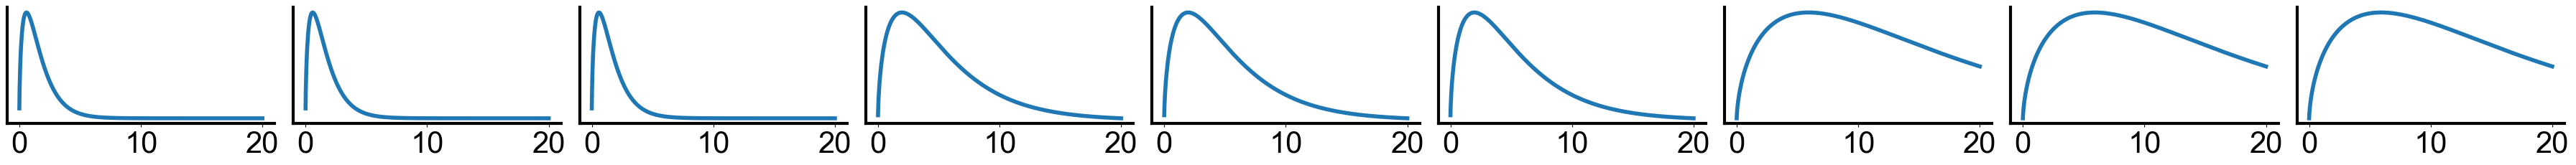

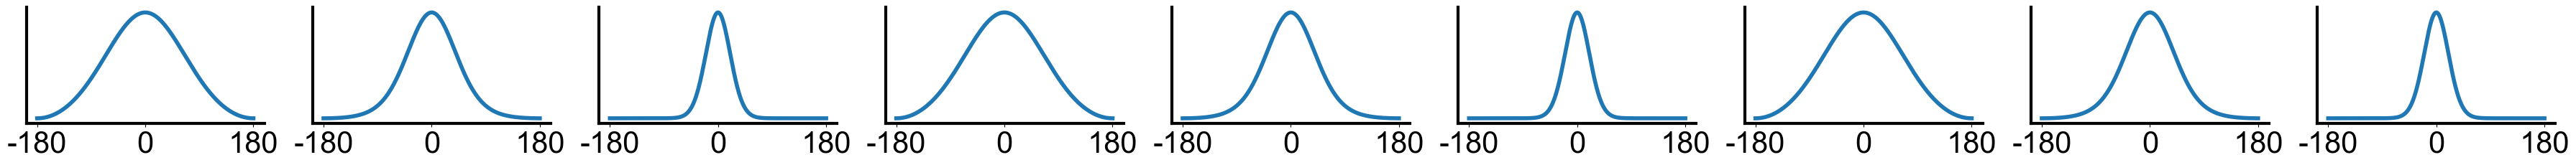

In [29]:
# open the file in read mode
file_path = ppath / 'tuning_prof.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    Tuning = file['D']
    Tuning = np.array(Tuning)
    print(Tuning.shape)

T2 = np.vstack((Tuning[:,0], Tuning[:,0],Tuning[:,0], Tuning[:,1], Tuning[:,1],Tuning[:,1], Tuning[:,2], Tuning[:,2],Tuning[:,2]))
T1 = np.vstack((Tuning[:,3], Tuning[:,4],Tuning[:,5], Tuning[:,3], Tuning[:,4],Tuning[:,5], Tuning[:,3], Tuning[:,4],Tuning[:,5]))
x1,x2 = np.linspace(0,20,1000), np.linspace(-180,180,1000)
for j in range(2):
    _, ax = plt.subplots(1,9,figsize=(figS*6,figS*0.4))
    for i in range(9):
        if j==1:
            ax[i].plot(x2,T1[i,:], linewidth=line_w+2)
            ax[i].set_xticks([-180,0,180])
            ax[i].set_xticklabels(["-180","0","180"])
            ax[i].set_yticks([])
            #ax[i].set_yticklabels(["0","0.1","0.2"])
        else:
            ax[i].plot(x1,T2[i,:],linewidth=line_w+2)
            ax[i].set_yticks([])
            #ax[i].set_yticklabels(["0","0.1","0.2"])
            ax[i].set_xticks([0,10,20])
            ax[i].set_xticklabels(["0","10","20"])
        ax[i].spines["top"].set_visible(False)
        ax[i].spines["right"].set_visible(False)
        for spine in ax[i].spines.values():
            spine.set_linewidth(3)
        ax[i].grid(False)
        for labl in (ax[i].get_xticklabels()+ax[i].get_yticklabels()):
            labl.set_fontname(f_font1["fontname"])
            labl.set_fontsize(f_font1["size"])
    plt.tight_layout()
    plt.show()

# Plotting CS predictions

In [5]:
def plot_response_grid(data_pair, mode, figS, parula_map, f_font1):
    """
    Plots a grid of temporal response fields.
    
    Args:
        data_pair: List of two arrays [data_A, data_B]
                   (e.g., [smeanfire1, smeanfire0])
        mode: 'first' (plots A), 'second' (plots B), or 'diff' (plots A - B)
        figS: Figure size scaling factor
        parula_map: Colormap
        f_font1: Font dictionary
    """
    # Extract dimensions (Assumes shape [..., 0, P, N])
    P = data_pair[0].shape[3]
    N = data_pair[0].shape[4]
    
    # Configure Mode Logic
    if mode == 'second':   # Plots T[1]
        get_data = lambda p, n: data_pair[1][:,:,0,p,n]
        vlim = (0, 0.8)
    elif mode == 'first':  # Plots T[0]
        get_data = lambda p, n: data_pair[0][:,:,0,p,n]
        vlim = (0, 0.8)
    elif mode == 'diff':   # Plots T[0] - T[1]
        get_data = lambda p, n: data_pair[0][:,:,0,p,n] - data_pair[1][:,:,0,p,n]
        vlim = (-0.8, 0.8)
    else:
        raise ValueError("Mode must be 'first', 'second', or 'diff'")

    # Setup Plot
    _, ax = plt.subplots(P, N, figsize=(figS*N, figS*P))
    ax = ax.flatten()
    
    # Ticks Configuration
    tckix = [0, 45, 90]
    tckvalx = ["-180", "0", "180"]
    tckvaly = ["180", "0", "-180"]

    a = 0
    for p in range(P):
        for n in range(N):
            # 1. Get and Transform Data
            img = get_data(p, n)
            img = np.flip(img.T, axis=0)
            
            # 2. Plot
            ax[a].imshow(img, cmap=parula_map, vmin=vlim[0], vmax=vlim[1])
            
            # 3. Styling
            ax[a].spines["top"].set_visible(False)
            ax[a].spines["right"].set_visible(False)
            ax[a].grid(False)
            
            # 4. Ticks & Labels
            ax[a].yaxis.set_ticks(tckix)
            ax[a].yaxis.set_ticklabels(tckvaly)
            ax[a].xaxis.set_ticks(tckix)
            ax[a].xaxis.set_ticklabels(tckvalx)
            
            # 5. Apply Fonts
            for labl in (ax[a].get_xticklabels() + ax[a].get_yticklabels()):
                labl.set_fontname(f_font1["fontname"])
                labl.set_fontsize(f_font1["size"])
            
            ax[a].tick_params(axis='x', which='major', pad=12)
            a += 1

    plt.tight_layout()
    plt.show()

--- Plotting Second Element (T[1]) ---


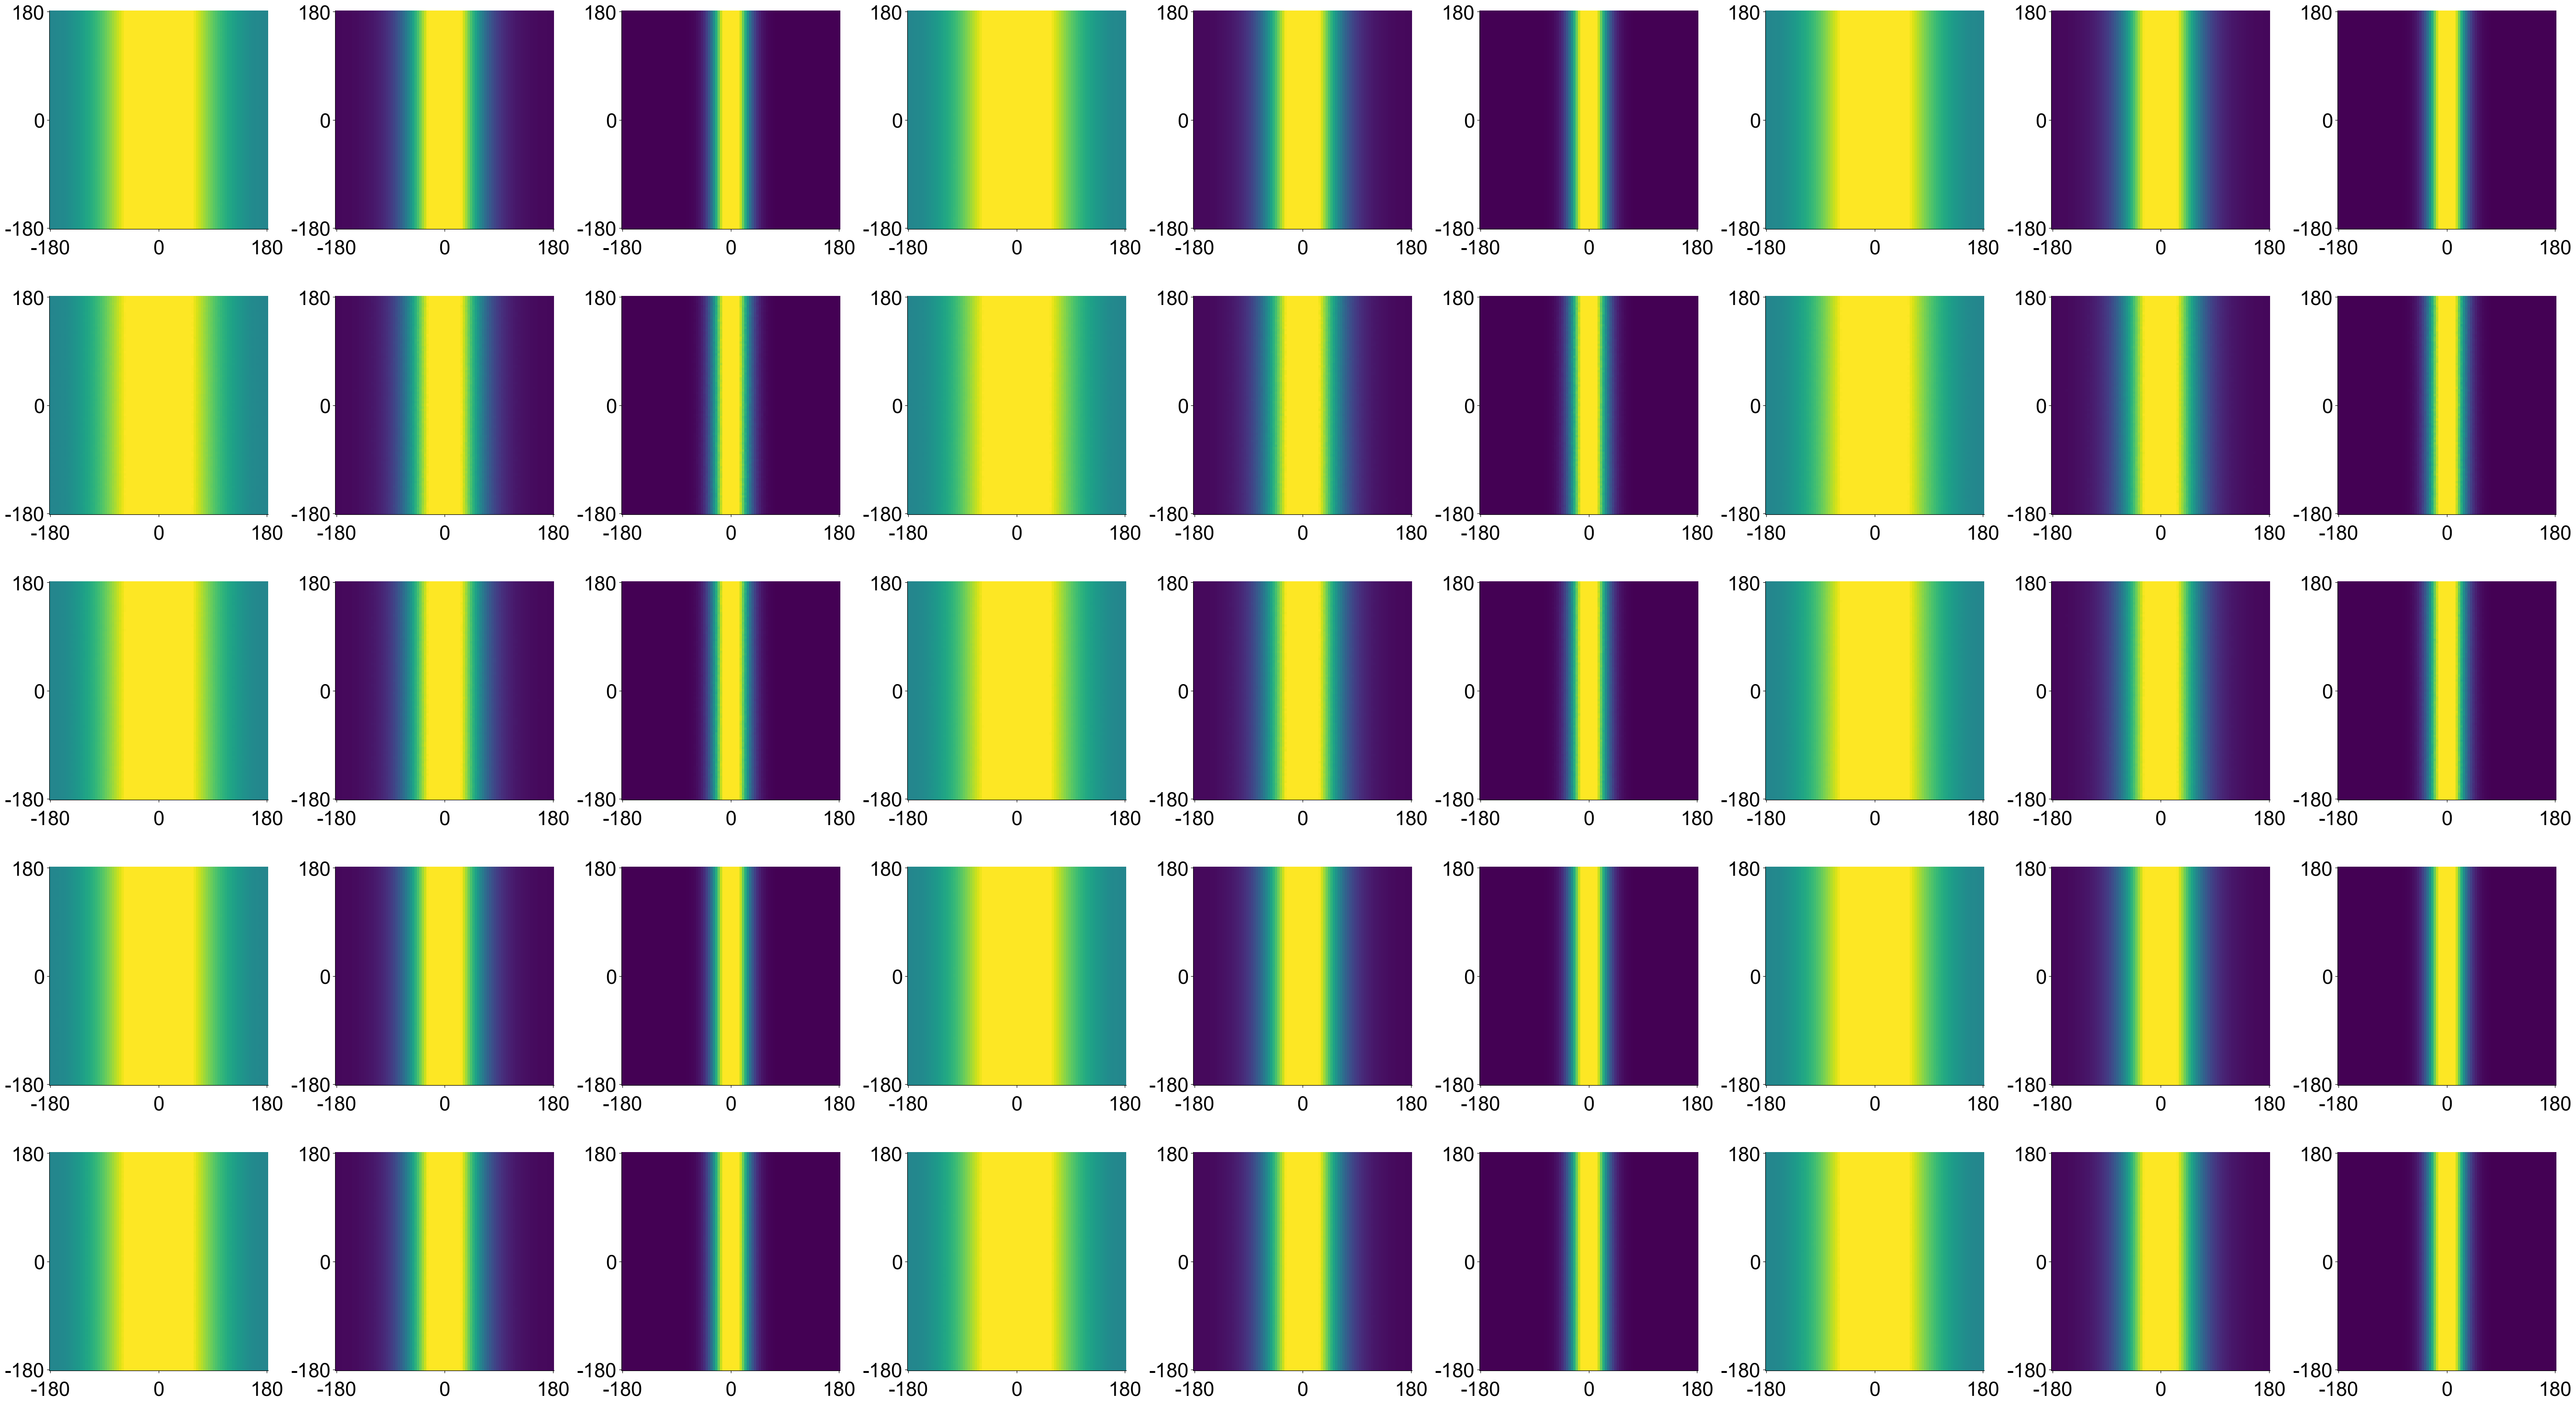

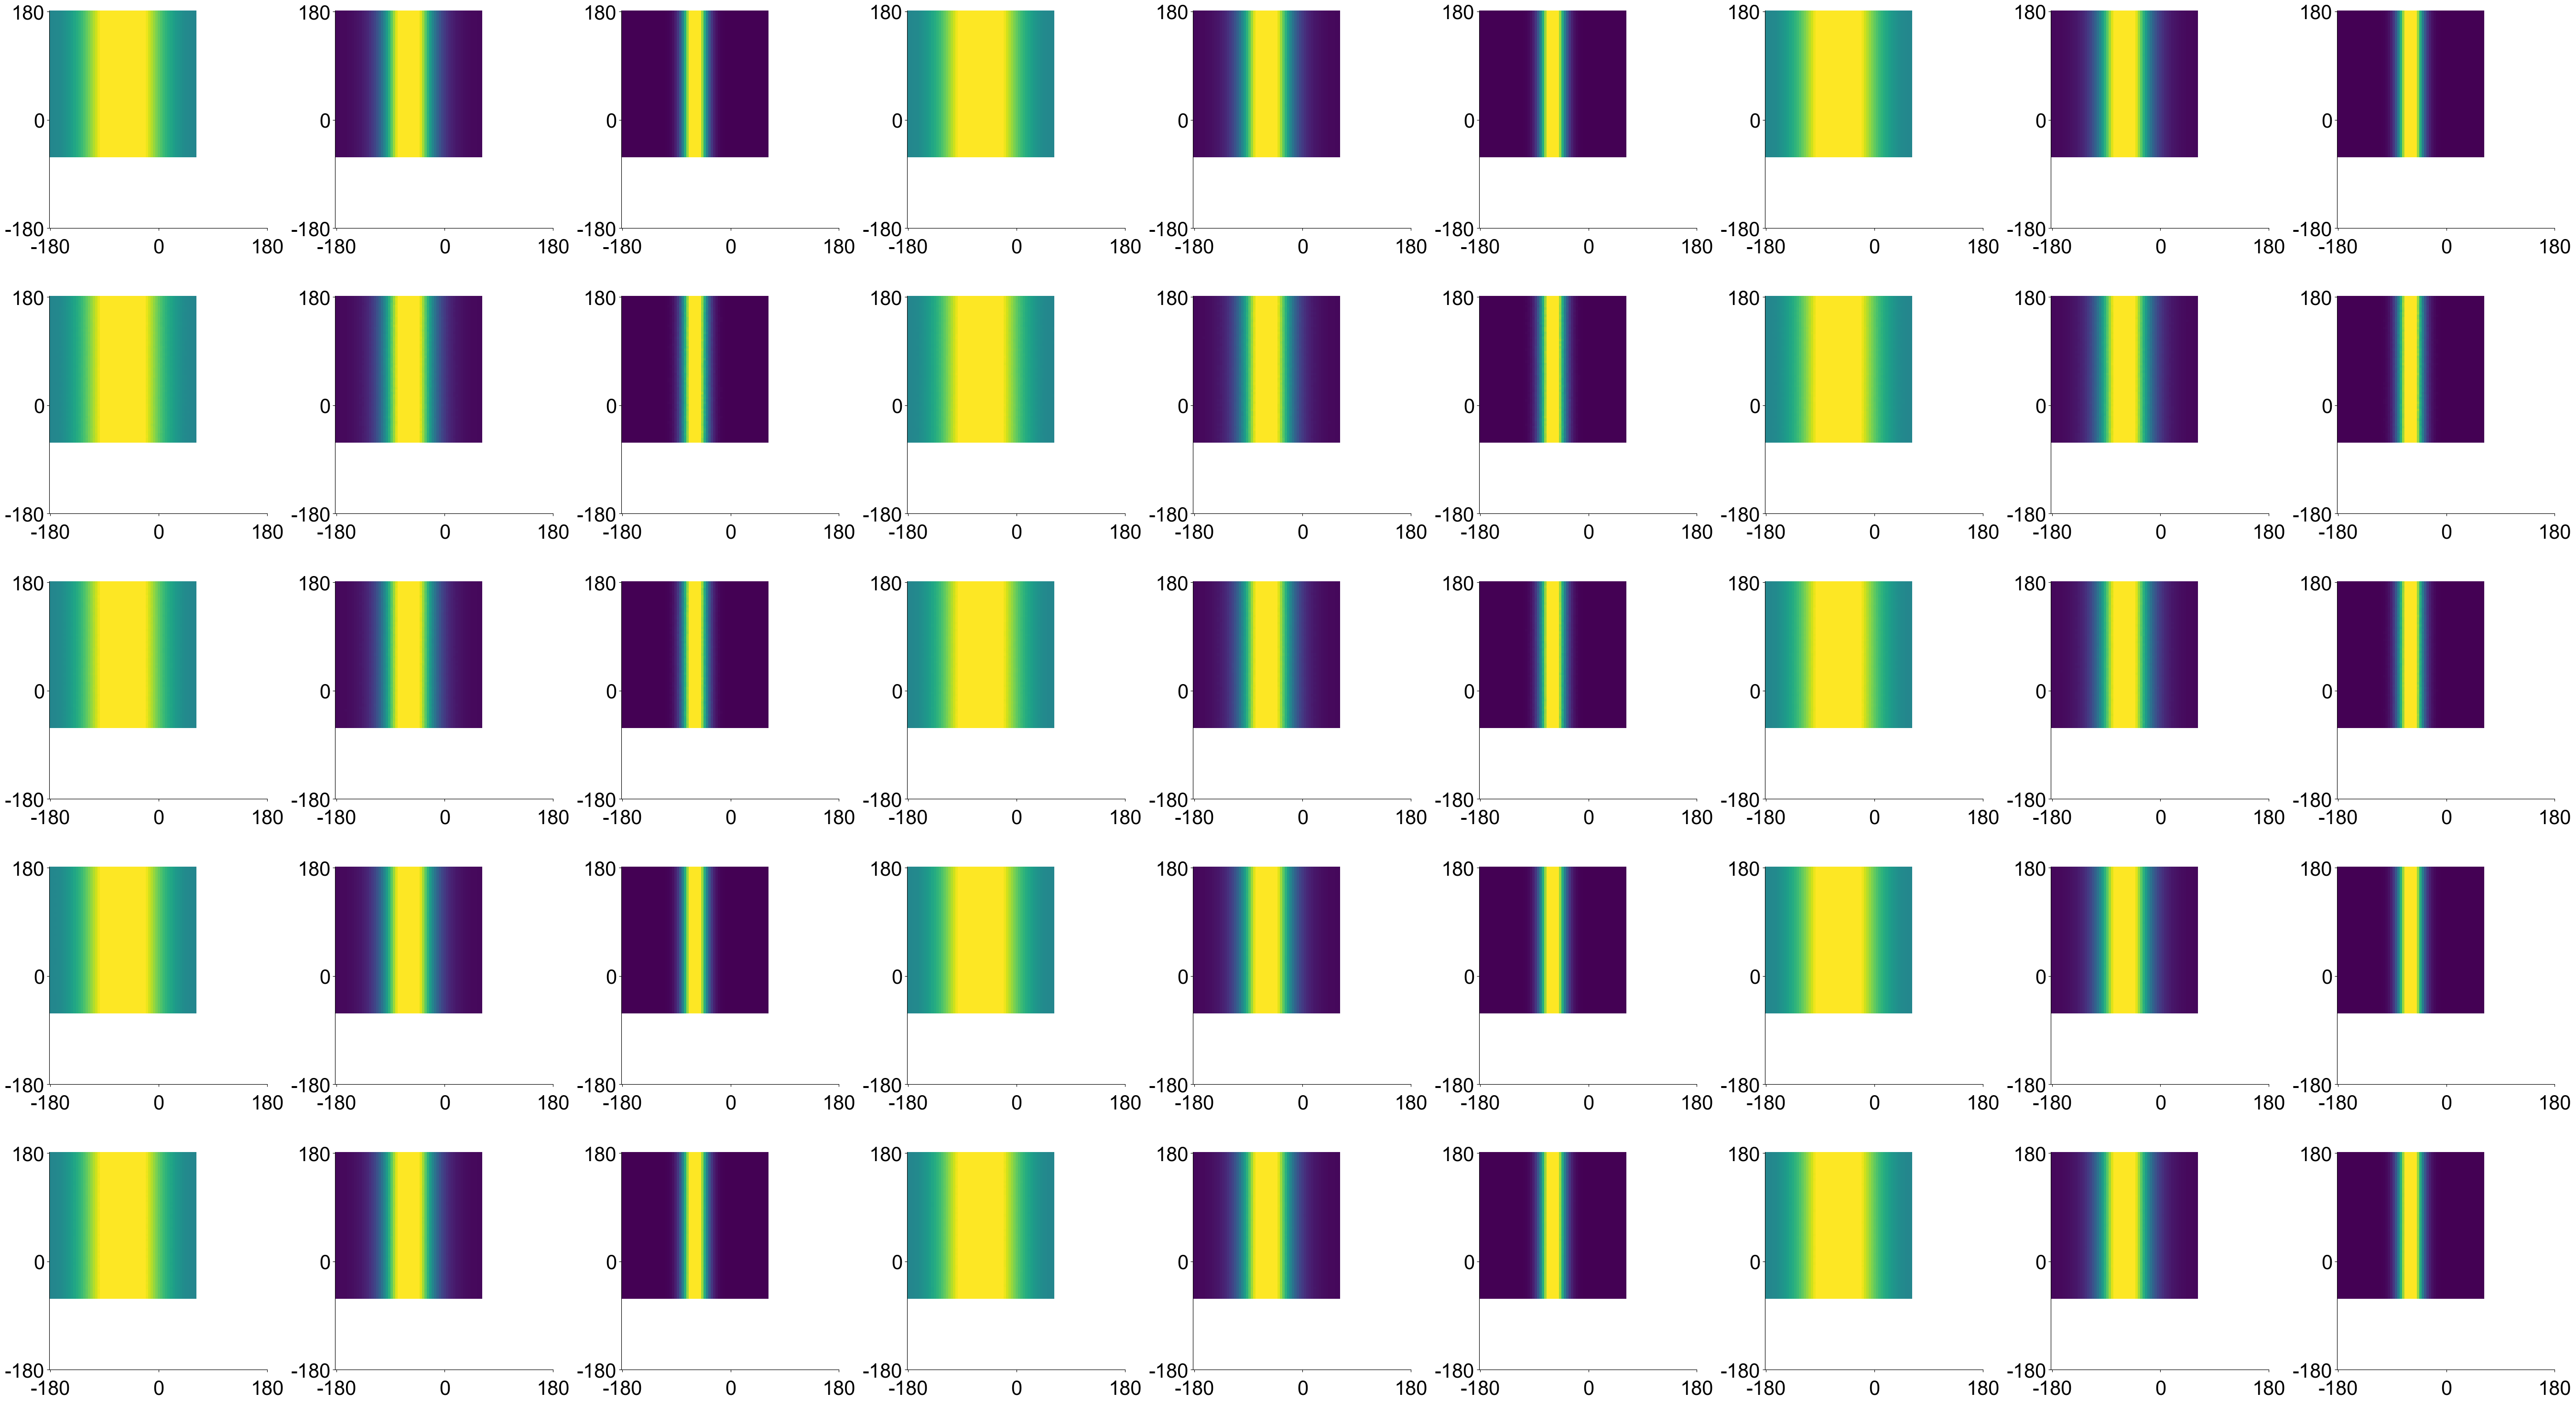

--- Plotting First Element (T[0]) ---


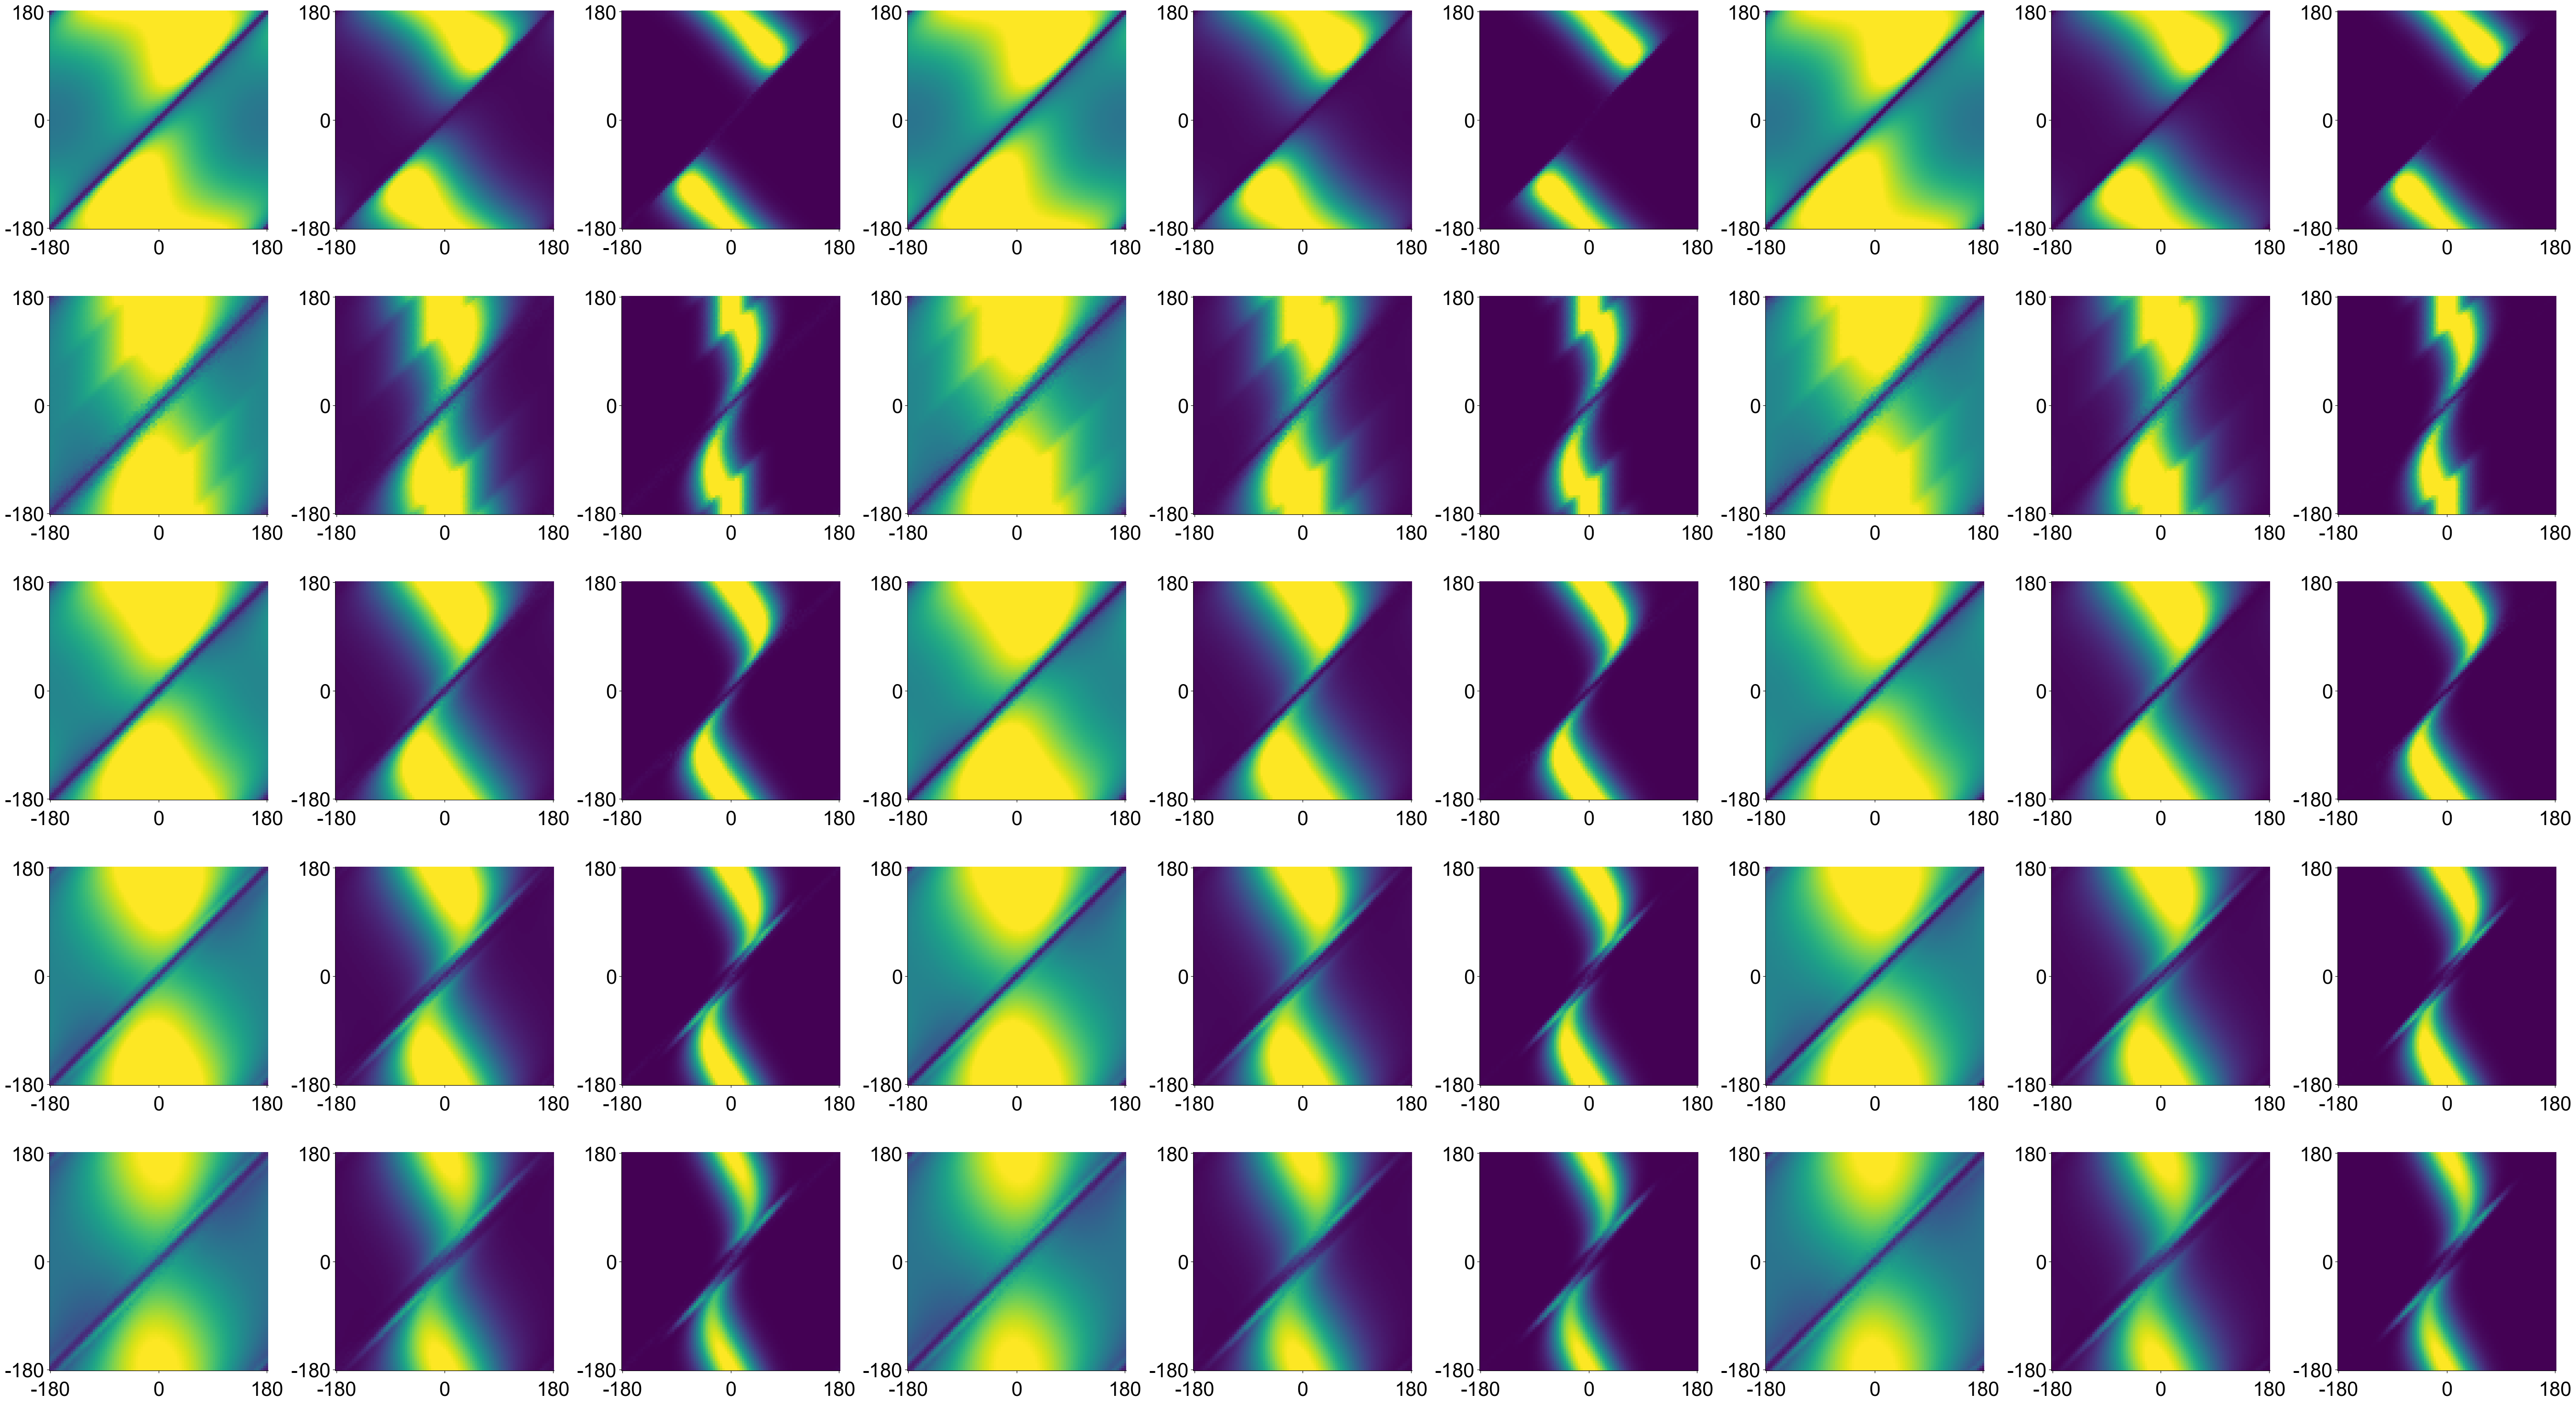

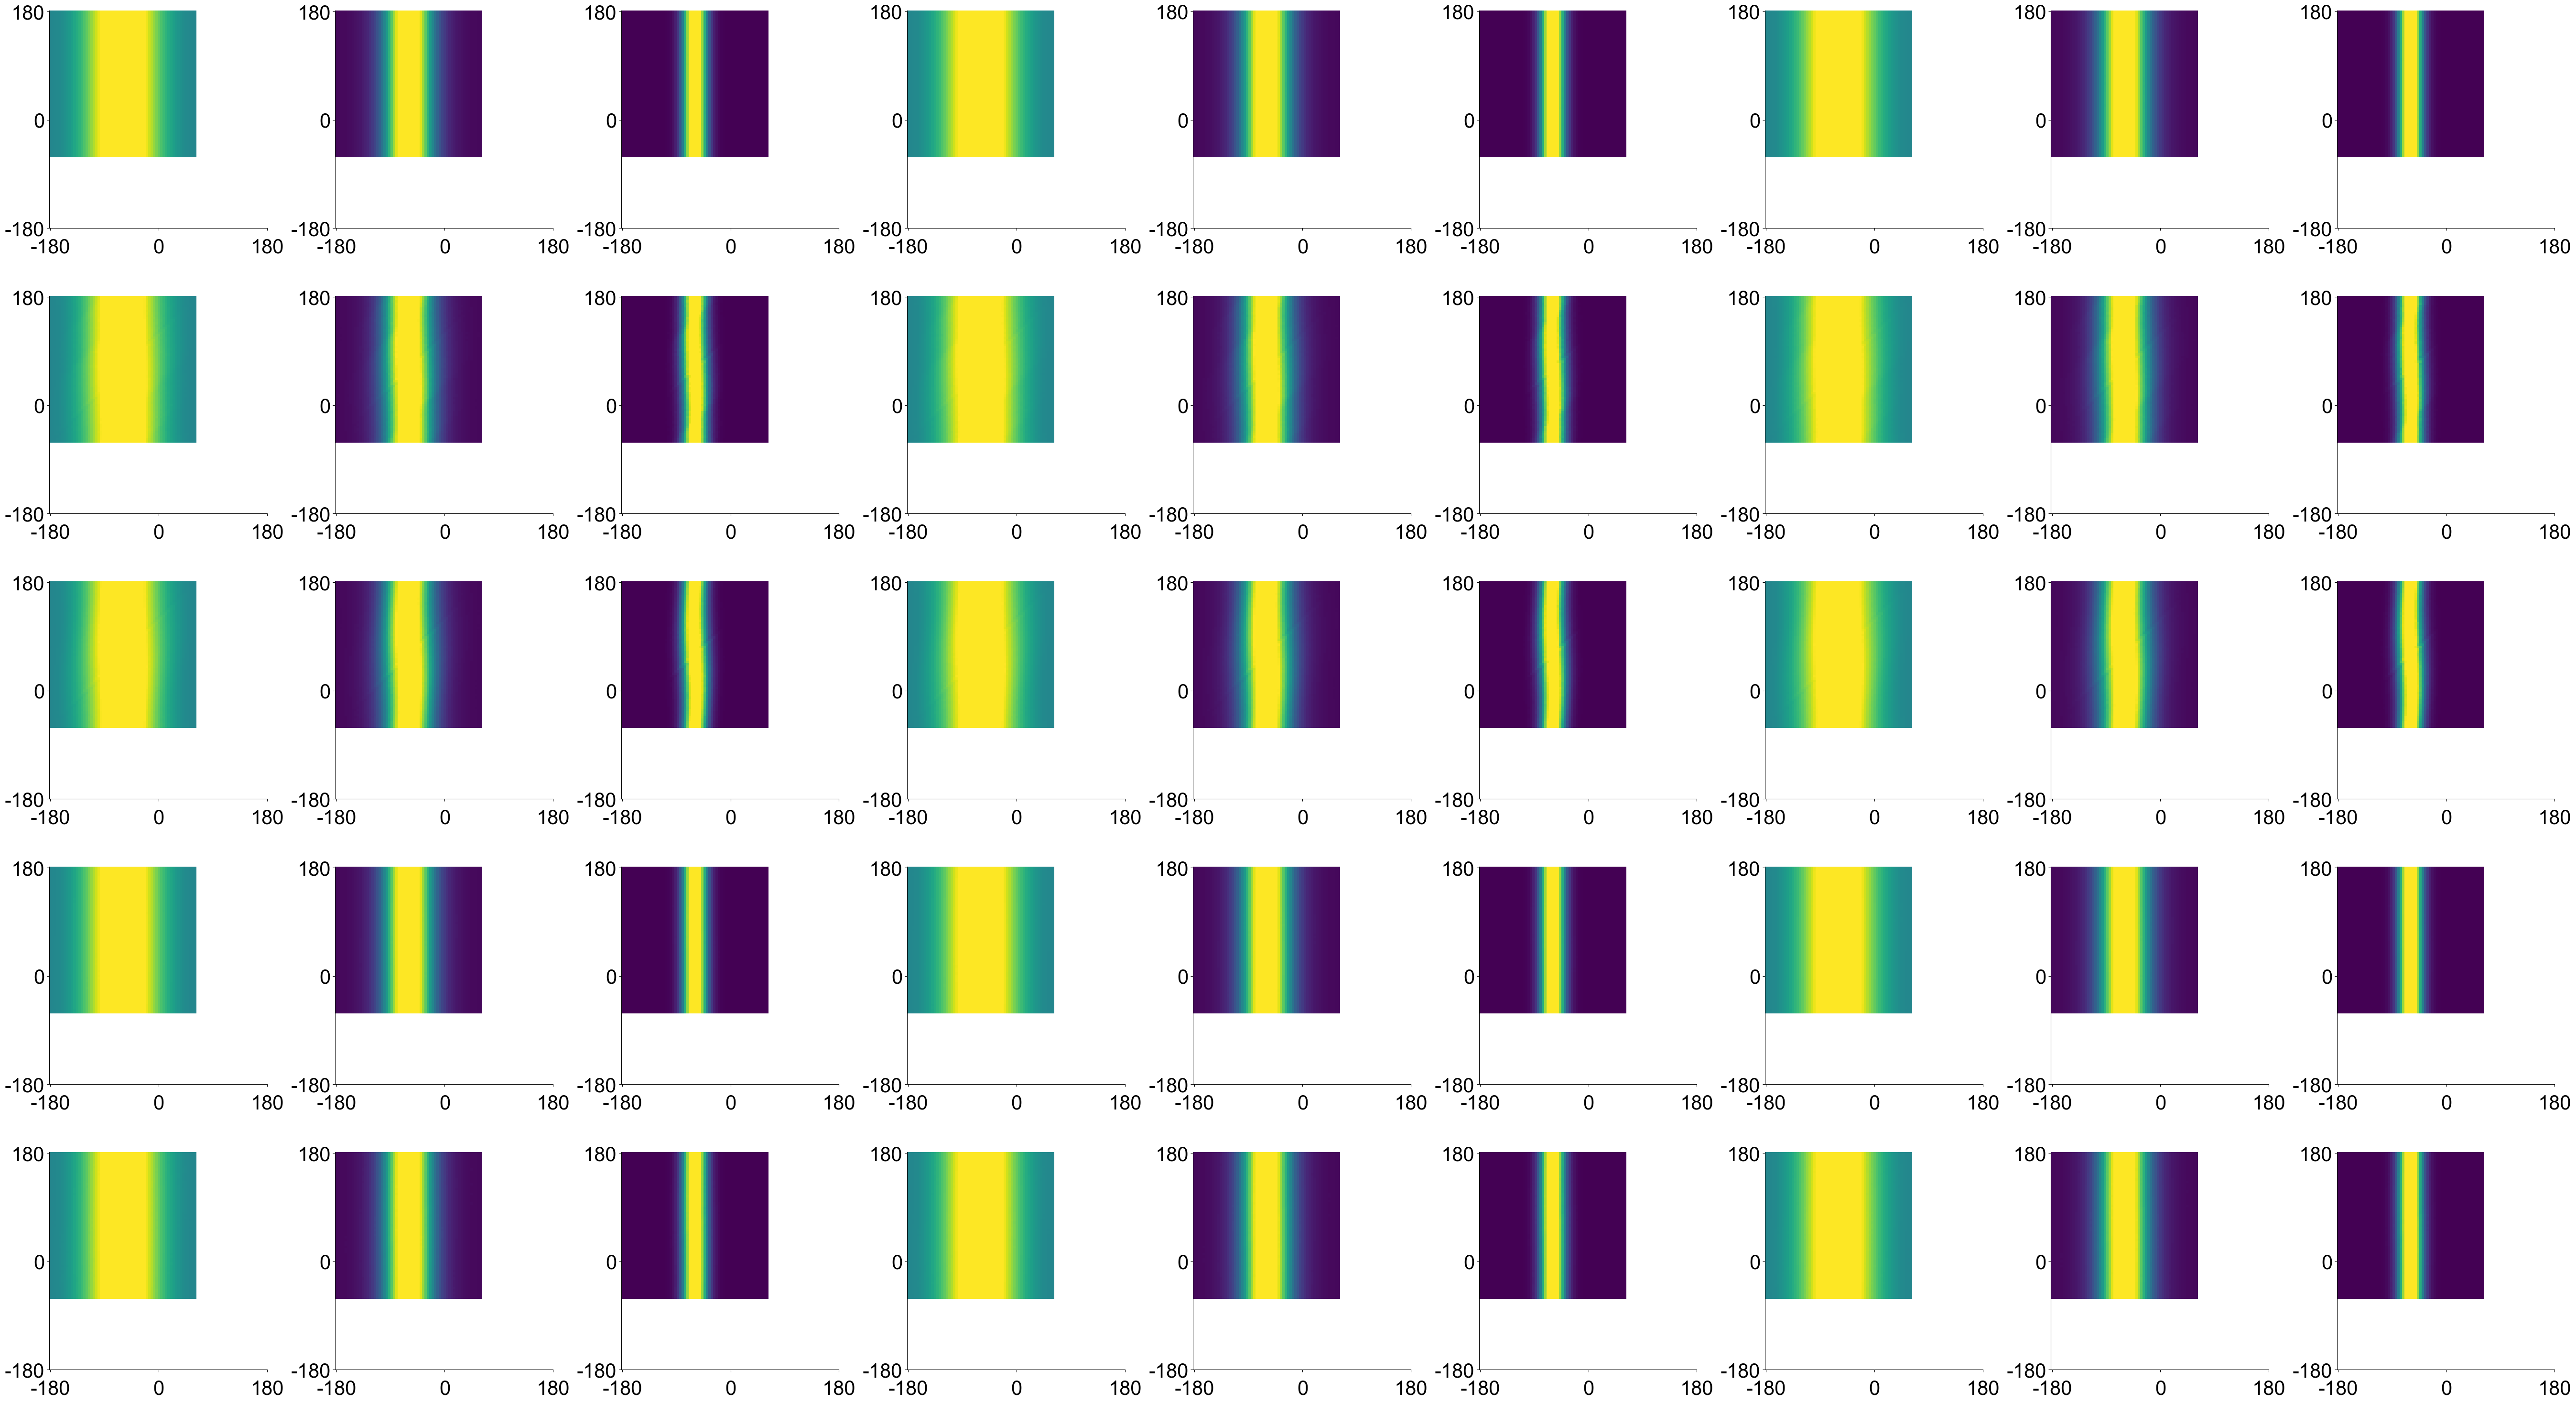

--- Plotting Difference ---


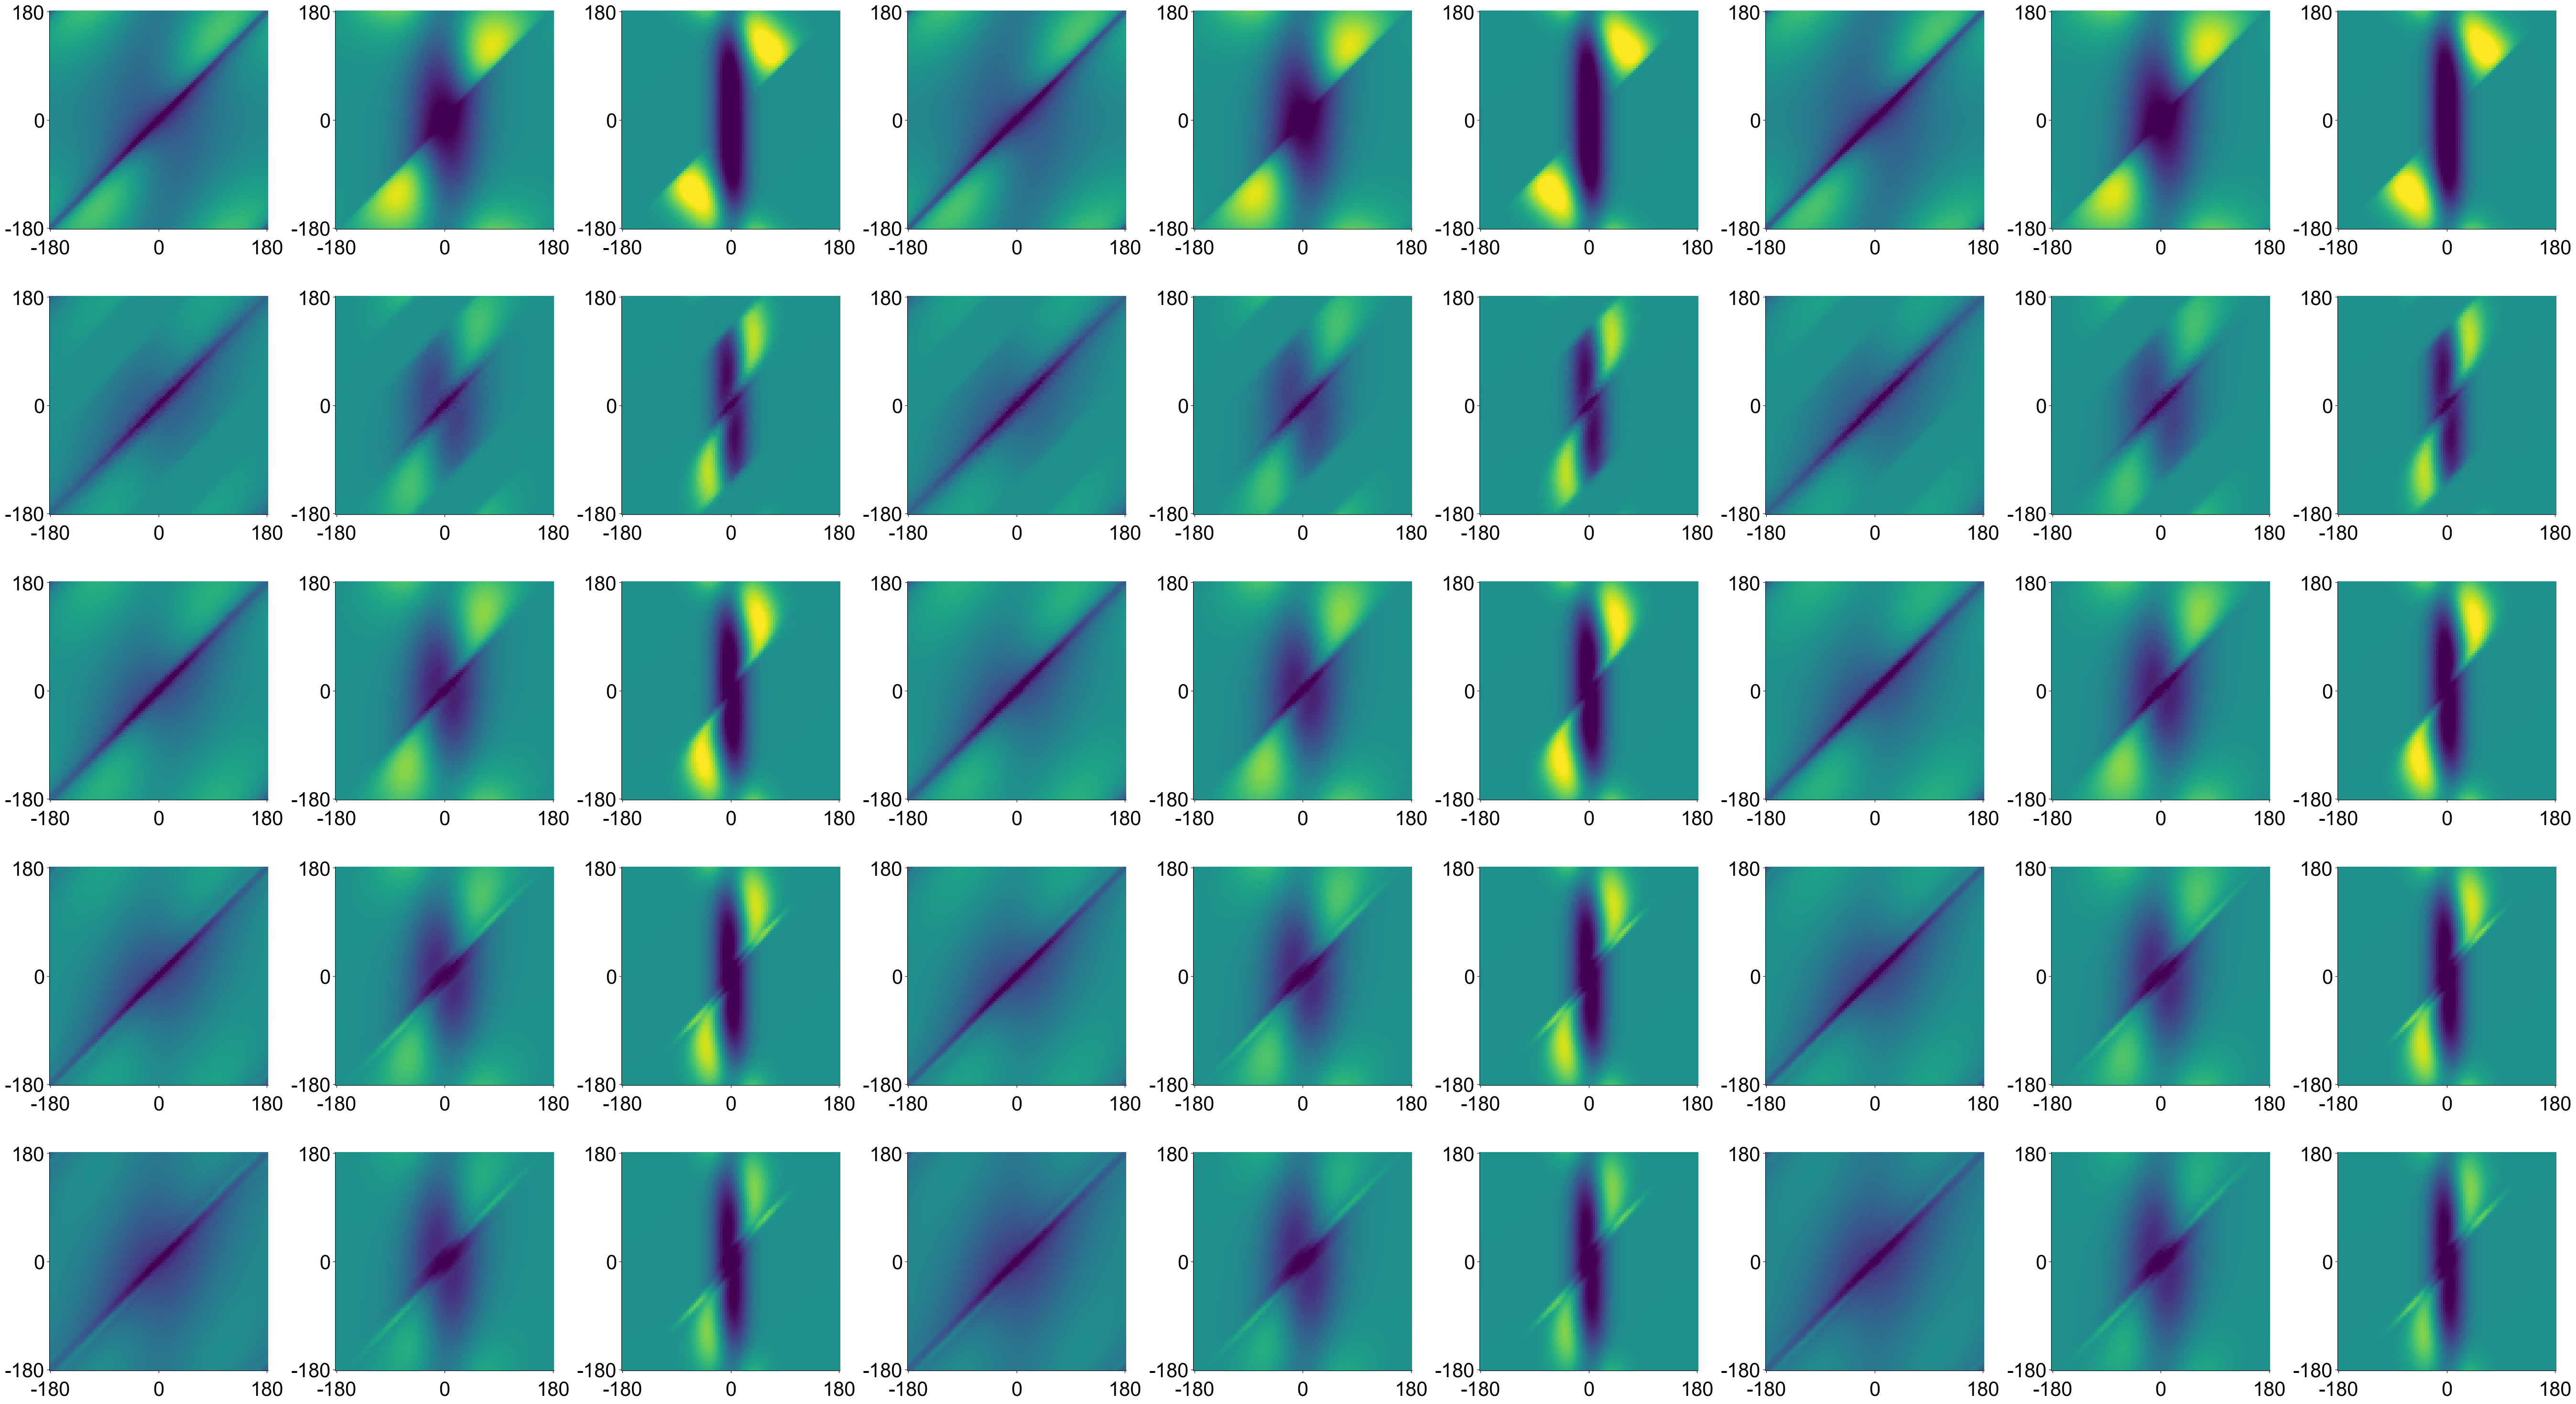

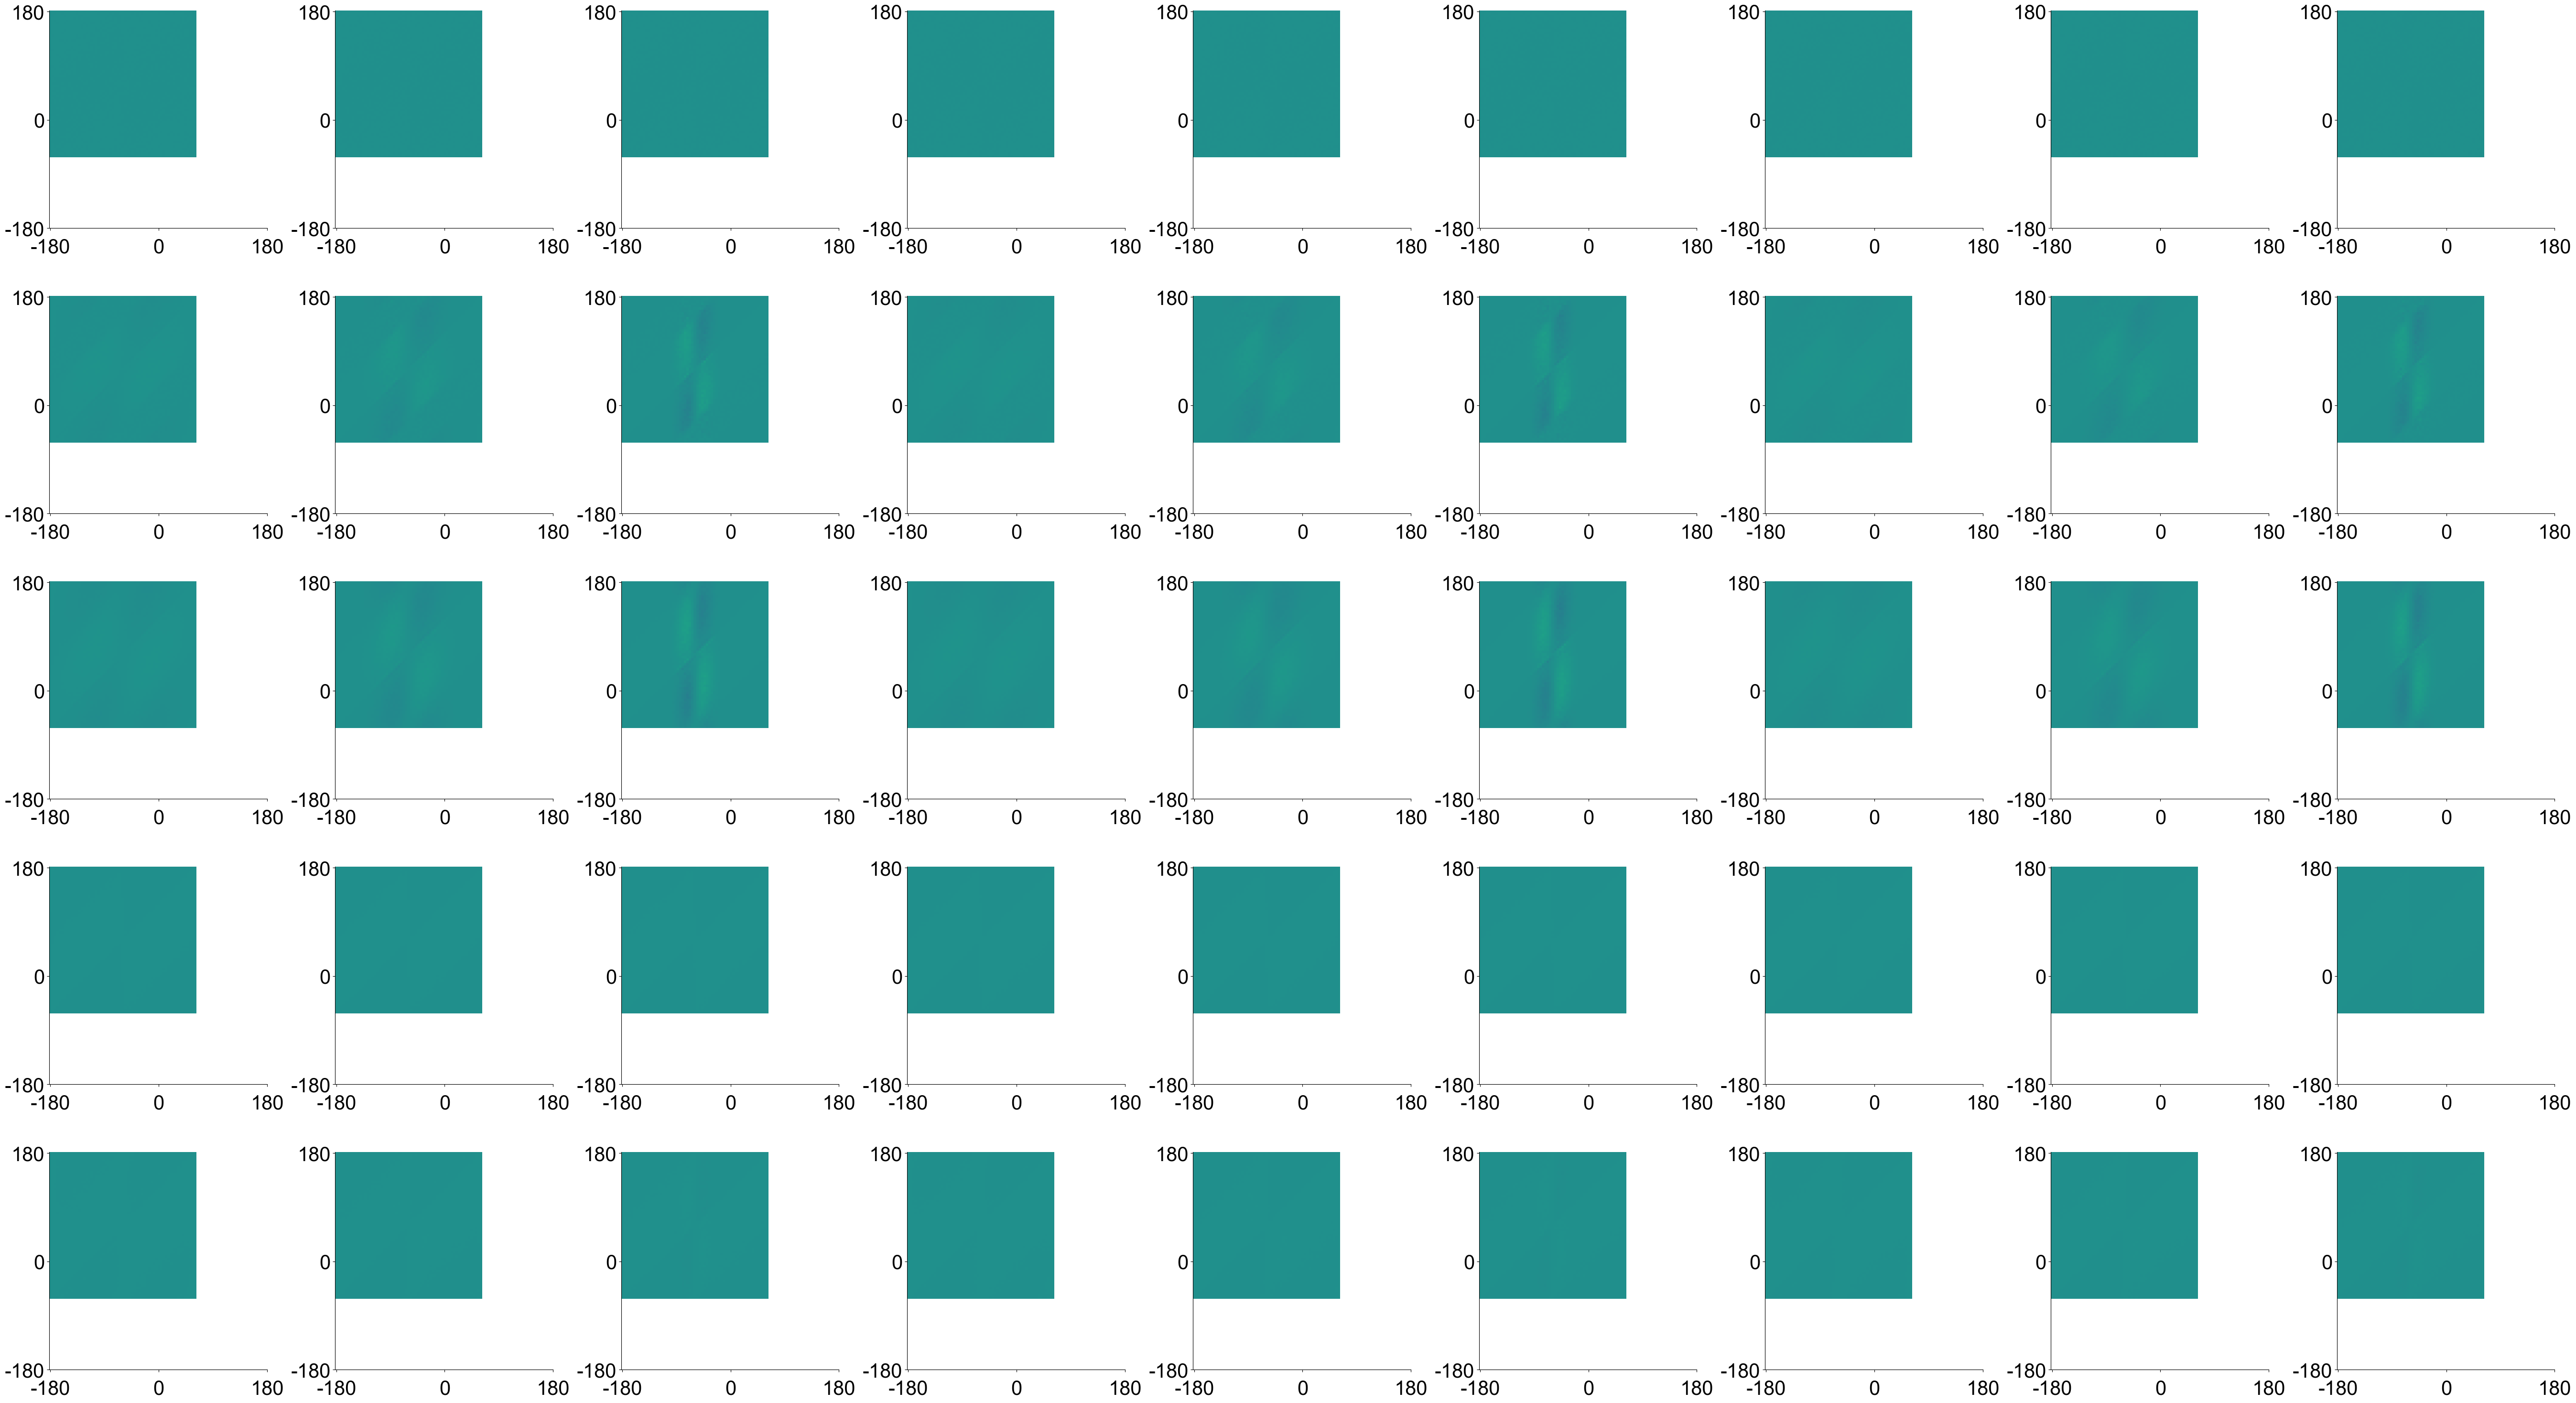

In [6]:
dataset_pairs = [[smeanfire1, smeanfire0], [gmeanfire1, gmeanfire0]]

# 1. Replaces Block 1 (Plots T[1] aka element 1)
print("--- Plotting Second Element (T[1]) ---")
for T in dataset_pairs:
    plot_response_grid(T, 'second', figS, parula_map, f_font1)

# 2. Replaces Block 2 (Plots T[0] aka element 0)
print("--- Plotting First Element (T[0]) ---")
for T in dataset_pairs:
    plot_response_grid(T, 'first', figS, parula_map, f_font1)

# 3. Replaces Block 3 (Plots Difference T[0] - T[1])
print("--- Plotting Difference ---")
for T in dataset_pairs:
    plot_response_grid(T, 'diff', figS, parula_map, f_font1)

# CS prediction cross sections that previous studies tested 

In [23]:
def plot_feature_difference(data_pairs, mode, config, env_params):
    """
    Unified plotter where dimensions (R, E, P, N) are computed dynamically.
    """
    # Unpack only styling content
    figS, line_w = env_params['figS'], env_params['line_w']
    f_font1 = env_params['f_font1']
    colors = ["royalblue", "olivedrab", "firebrick"]

    for v, T in enumerate(data_pairs):
        
        # --- 1. Compute Dimensions Dynamically ---
        # robustly handles 4D (speed) or 5D (direction)
        # Assumes structure: [R, (optional W), E, P, N]
        R_current = T[0].shape[0] 
        E = T[0].shape[-3]
        P = T[0].shape[-2]
        N = T[0].shape[-1]
        
        y_data = range(R_current)

        # --- 2. Mode Configuration ---
        if mode == 'direction':
            # Config specific to dataset index v
            if v == 0:
                ix1 = 45
                tckixM = [0, 45, 90]
            else:
                ix1 = 30
                tckixM = [0, 30, 60]
            
            # Helper: Slice 5D array -> Flip/Transpose -> Extract Column
            def get_data(T_arr, e_idx, p_idx, n_idx):
                t1 = np.flip(T_arr[0][:,:,e_idx,p_idx,n_idx].T, axis=0)
                t2 = np.flip(T_arr[1][:,:,e_idx,p_idx,n_idx].T, axis=0)
                return t1[:, ix1] - t2[:, ix1]
                
            y_ticks_labels = ["-180", "0", "180"]

        elif mode == 'speed':
            tckixM = [0, 2, 4]
            
            # Helper: Direct subtraction on 4D array
            def get_data(T_arr, e_idx, p_idx, n_idx):
                return T_arr[0][:,e_idx,p_idx,n_idx] - T_arr[1][e_idx,p_idx,n_idx]
            
            y_ticks_labels = ["1/4x", "1x", "4x"]

        # --- 3. Plotting Loop ---
        _, ax = plt.subplots(P, N, figsize=(figS*6, figS*2.2))
        ax = ax.flatten()
        a = 0
            
        for p in range(P):
            for n in range(N):
                for e in range(E):
                    diff_curve = get_data(T, e, p, n)
                    ax[a].plot(diff_curve, y_data, 'o-', linewidth=line_w+4, color=colors[e])
                
                # Reference Line logic
                ax[a].plot(np.zeros(len(tckixM)), tckixM, "k--", linewidth=line_w+2)        
                
                # Axes Styling
                ax[a].spines["top"].set_visible(False)
                ax[a].spines["right"].set_visible(False)
                ax[a].grid(False)
                for spine in ax[a].spines.values():
                    spine.set_linewidth(3)

                # Y-Axis
                ax[a].set_yticks(tckixM)
                ax[a].set_yticklabels(y_ticks_labels)
                
                # X-Axis limits
                if mode == 'direction':
                    ax[a].set_xlim(-1, 1)
                    ax[a].set_xticks([-1, 0, 1])
                    ax[a].set_xticklabels([" ", " ", " "])
                elif mode == 'speed':
                    ax[a].set_xlim(-1, 1.02)
                    ax[a].set_xticks([])
                
                # Fonts
                for labl in (ax[a].get_xticklabels() + ax[a].get_yticklabels()):
                    labl.set_fontname(f_font1["fontname"])
                    labl.set_fontsize(f_font1["size"])
                
                a += 1

        plt.tight_layout()
        if 'sp' in env_params and env_params['sp']:
            # Make sure it works whether 'sp' is a string or a Path object
            save_dir = str(env_params['sp']) 
            file_name = config['filename_base'] + str(v) + '.pdf'
            
            # Use os.path.join to insert the slash automatically
            full_path = os.path.join(save_dir, file_name)
            
            # Optional: Create folder if it doesn't exist
            # os.makedirs(save_dir, exist_ok=True)
            
            plt.savefig(full_path)
            
        plt.show()


# Loading the simulated predictions across CS speeds

In [24]:
# open the file in read mode
file_path = ppath / 'MF_5subj_full_rel.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    smeanfire0_s = file['meanfire'][45,45,2,0,:,:,:]
    smeanfire1_s = file['meanfire'][45,45,2,1:,:,:,:]
    smeanfire0_s = np.array(smeanfire0_s)
    print(smeanfire0_s.shape)
    smeanfire1_s = np.array(smeanfire1_s)
    print(smeanfire1_s.shape)

['meanfire']
(3, 5, 9)
(5, 3, 5, 9)


In [25]:
file_path = ppath / 'MF_cent_5subj.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    gmeanfire0_s = file['meanfire'][30,30,2,0,:,:,:]
    gmeanfire1_s = file['meanfire'][30,30,2,1:,:,:,:]
    gmeanfire0_s = np.array(gmeanfire0_s)
    print(gmeanfire0_s.shape)
    gmeanfire1_s = np.array(gmeanfire1_s)
    print(gmeanfire1_s.shape)

['meanfire']
(3, 5, 9)
(5, 3, 5, 9)


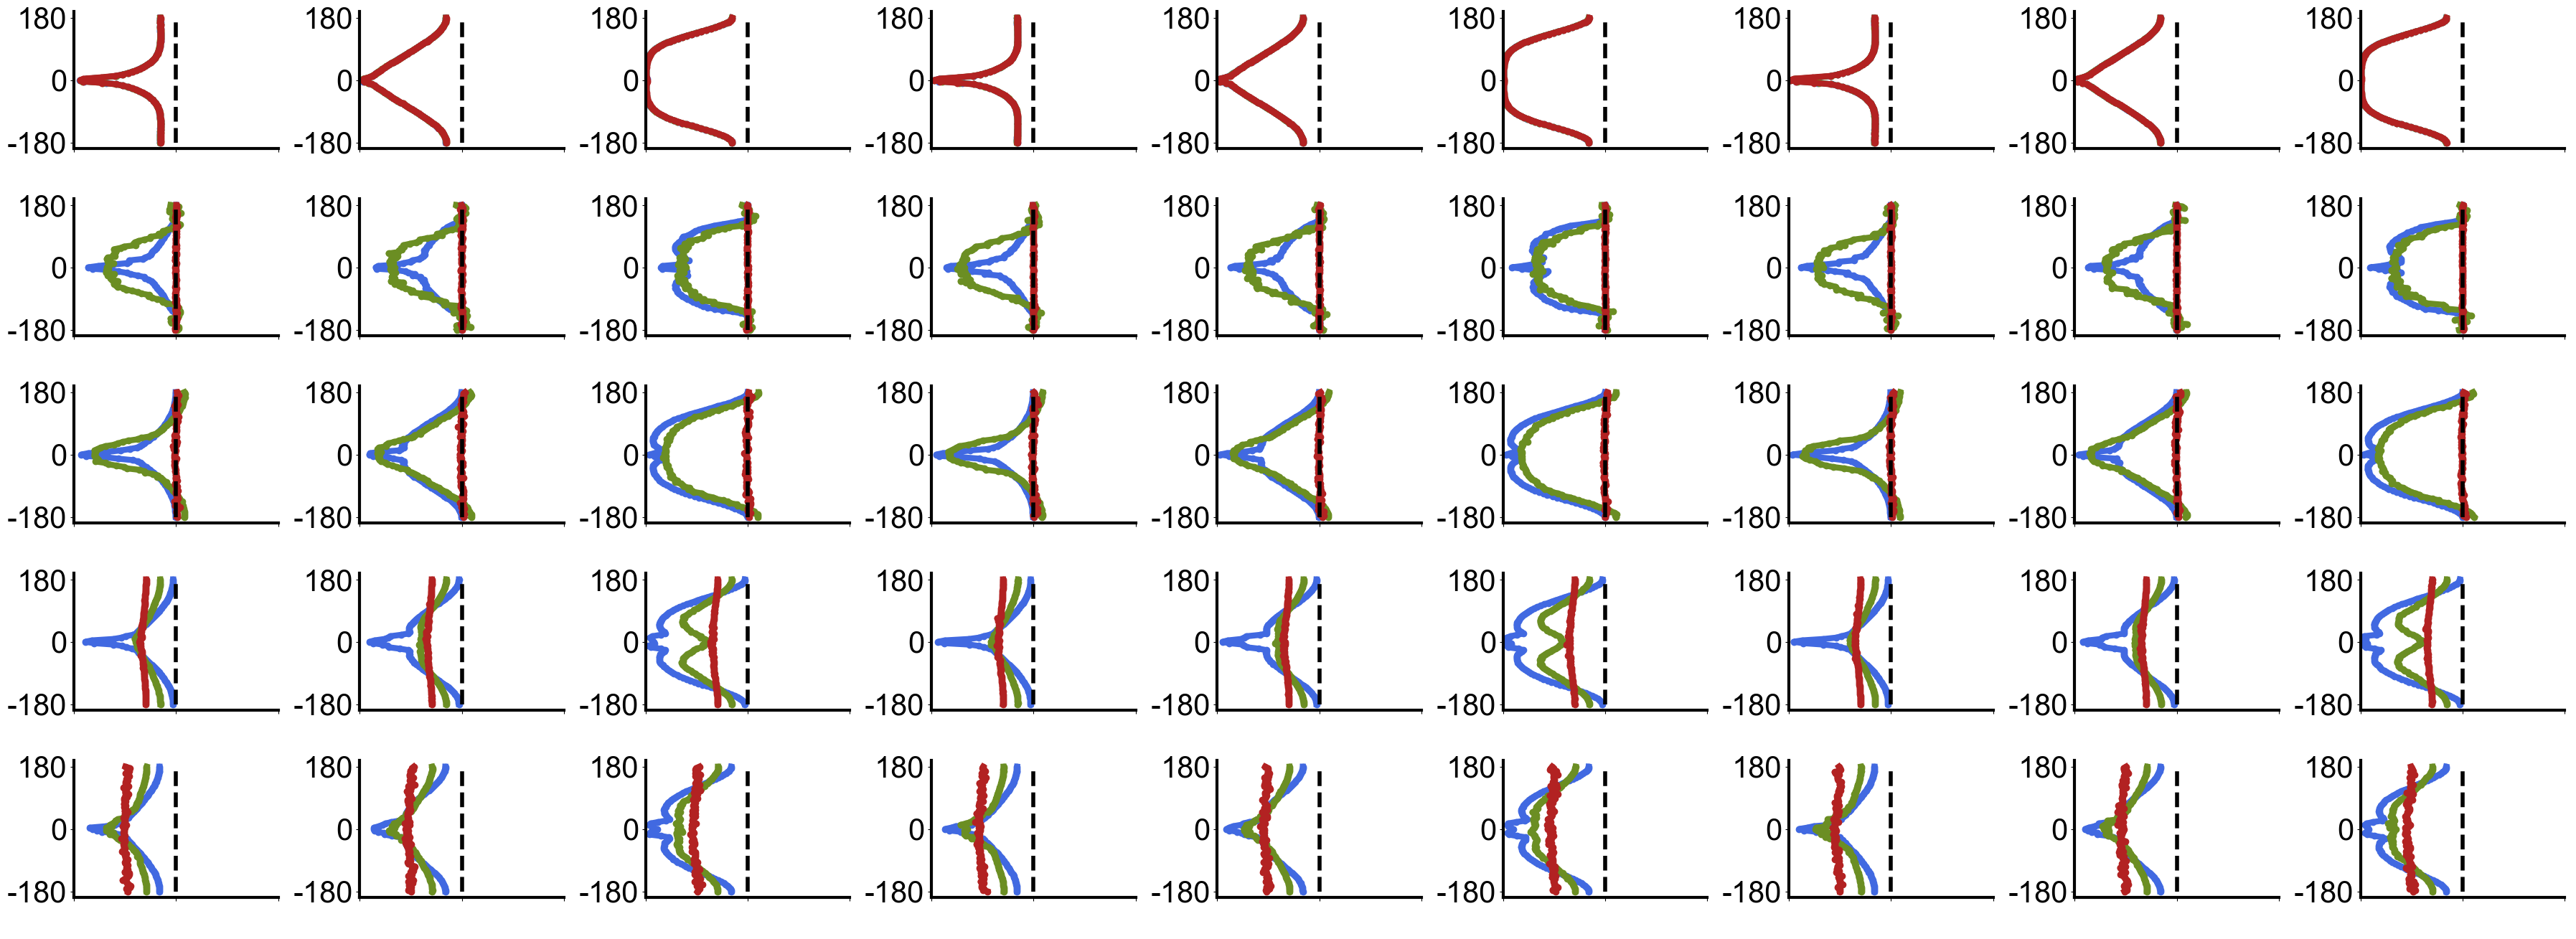

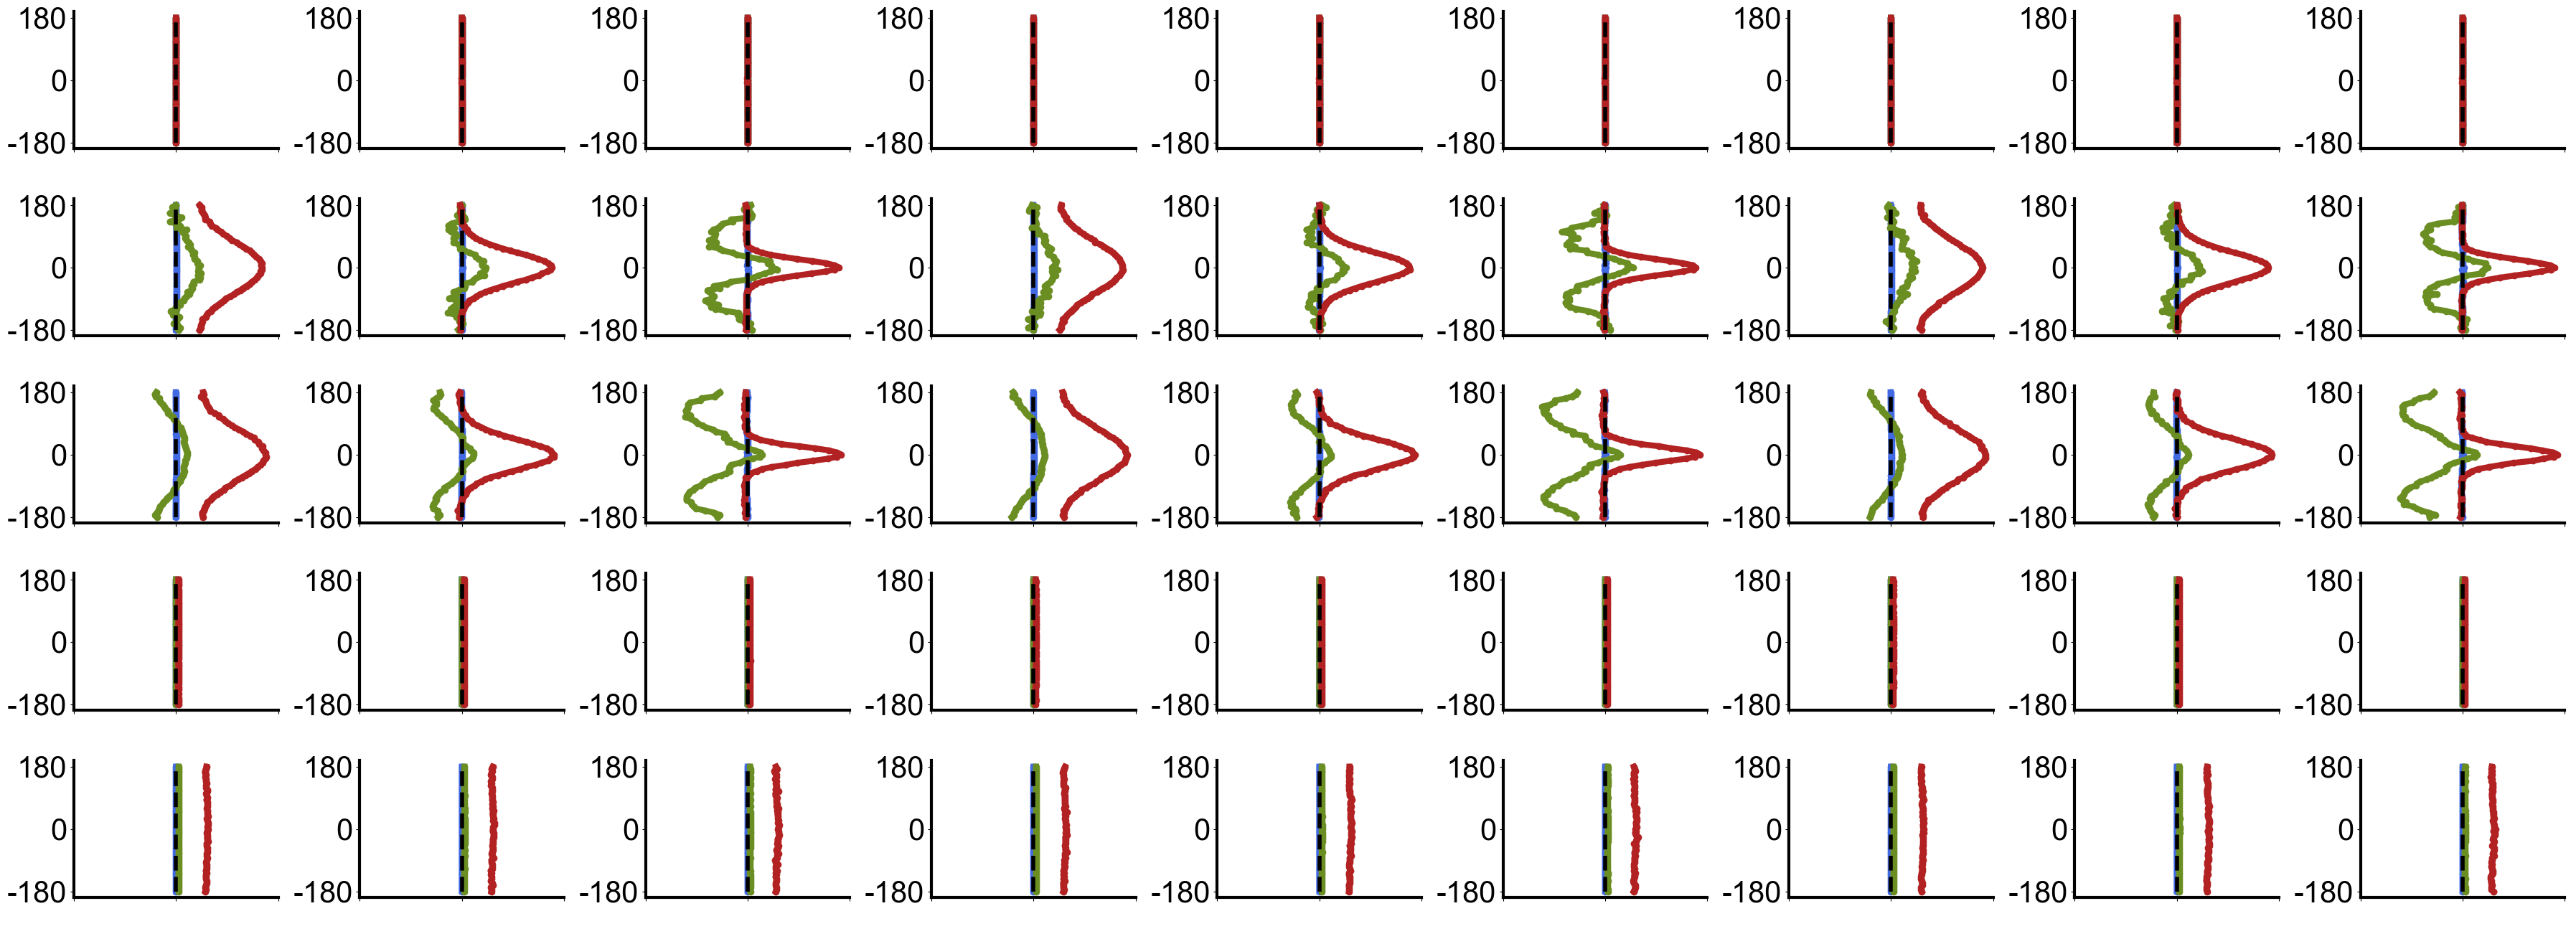

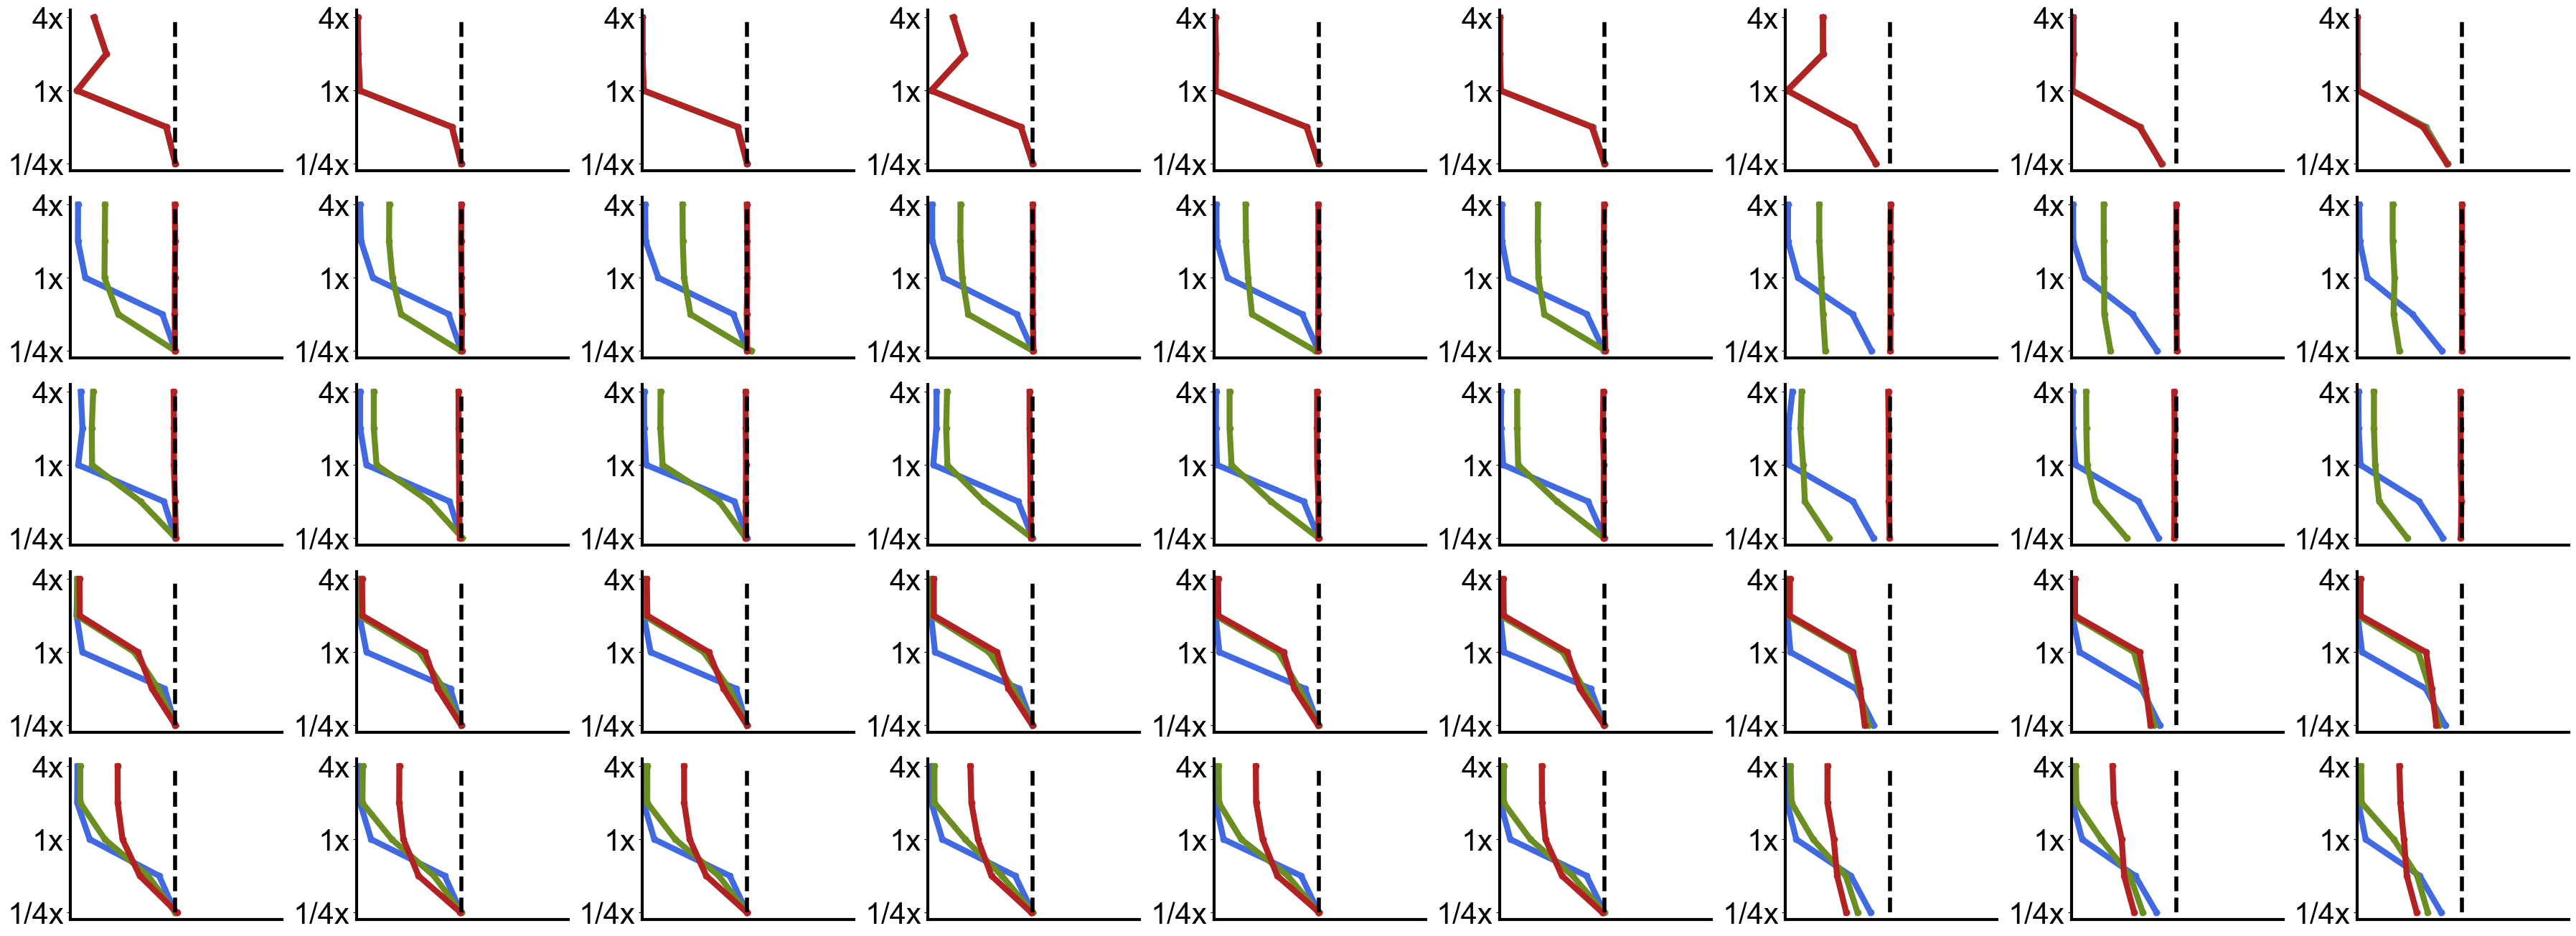

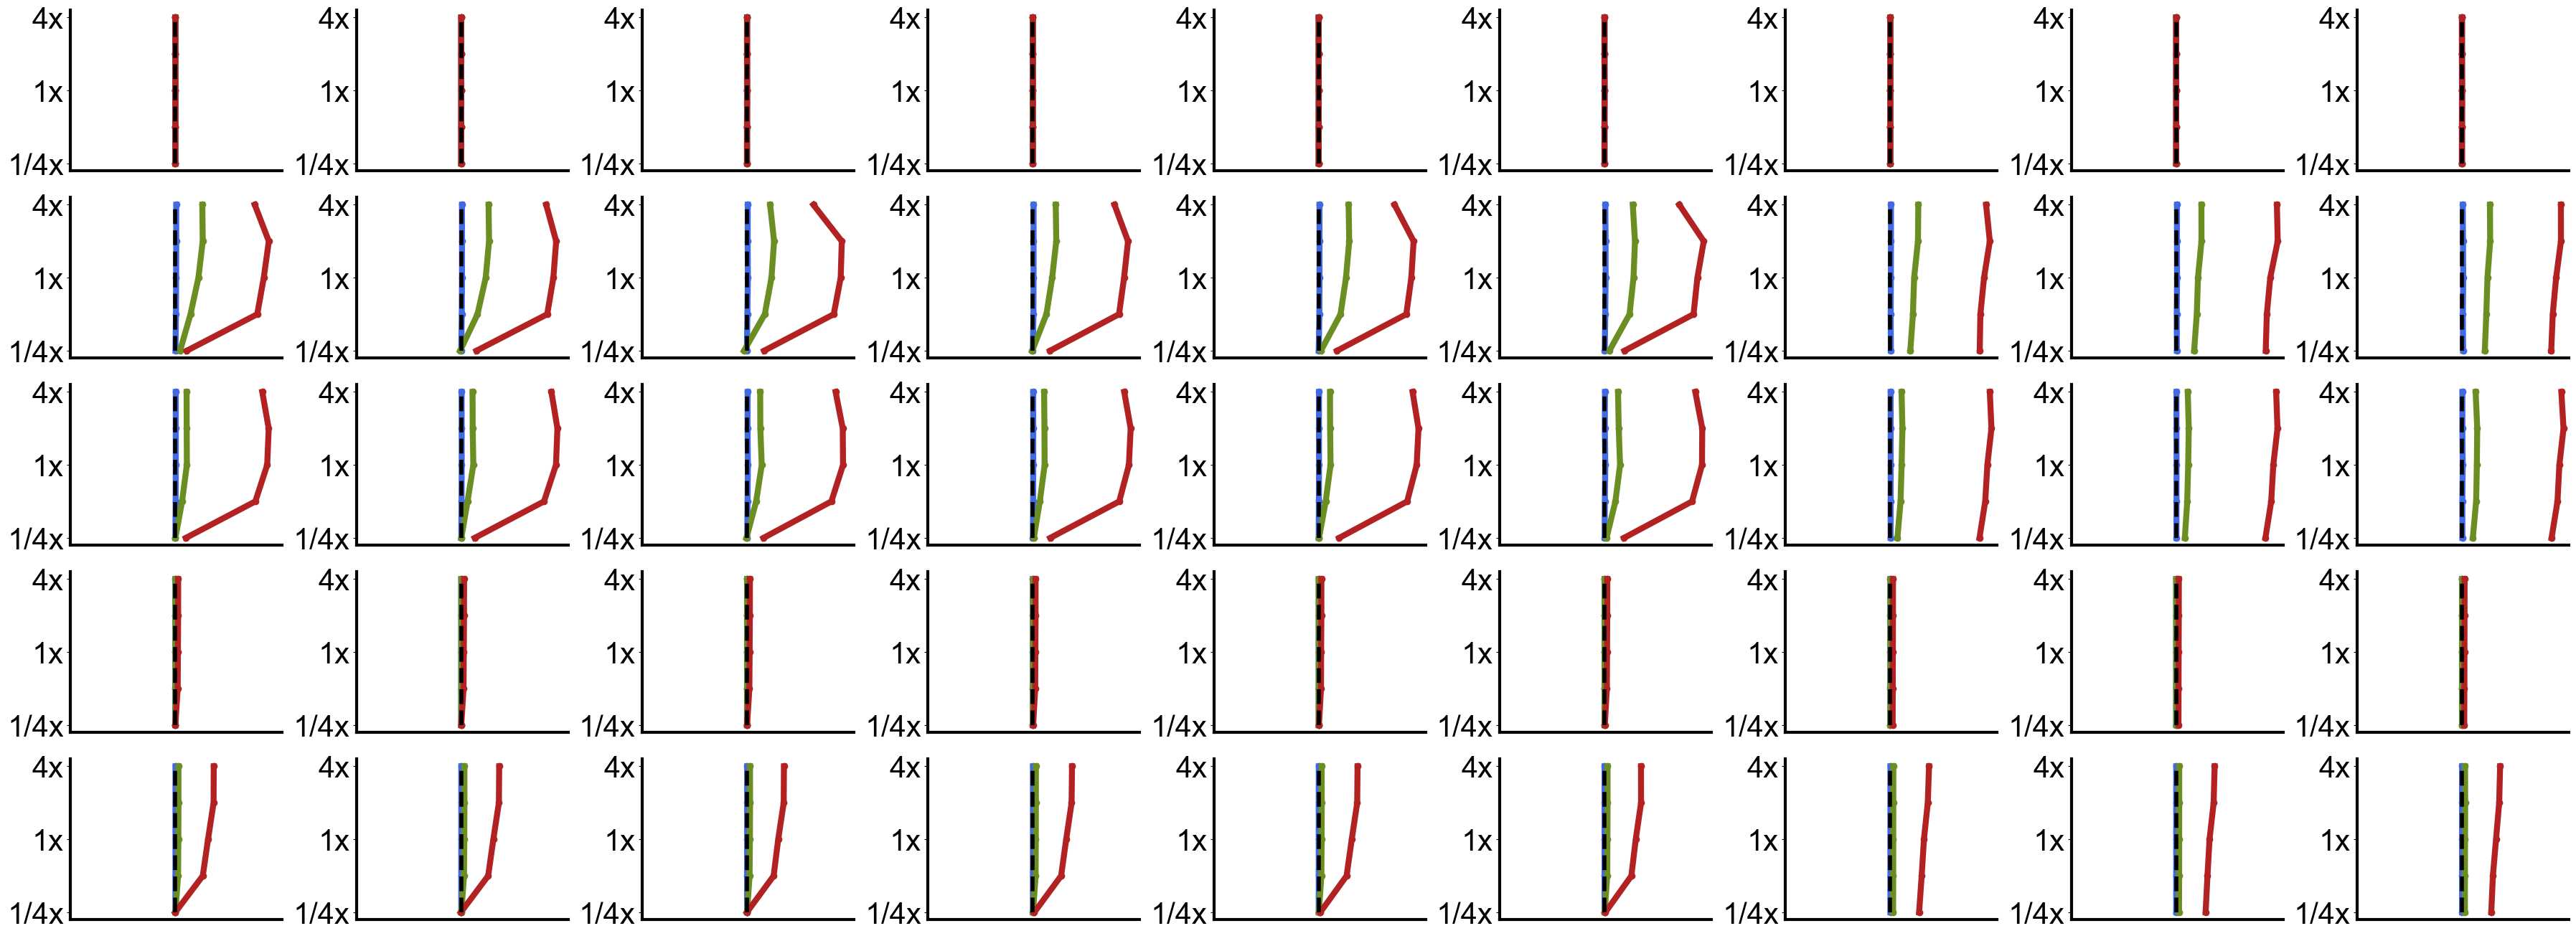

In [26]:


env = {
    'figS': figS, 'line_w': line_w,
    'f_font1': f_font1, 'sp': sp
}
# 1. Direction
plot_feature_difference(
    [[smeanfire1, smeanfire0], [gmeanfire1, gmeanfire0]], 
    'direction', 
    {'filename_base': 'Comp_allSubj_dir_cent_rel'}, 
    env
)
# 2. Speed
plot_feature_difference(
    [[smeanfire1_s, smeanfire0_s], [gmeanfire1_s, gmeanfire0_s]], 
    'speed', 
    {'filename_base': 'Comp_allSubj_spd_'}, 
    env
)

# Fitting the empirical data qualitatively
## Starting with the predictions across CS directions

In [34]:
def save_and_show(save_path, filename):
    """Helper to save and show the plot."""
    if save_path:
        # ensuring robust path joining
        full_path = os.path.join(save_path, filename)
        plt.savefig(full_path)
    plt.show()

def plot_heatmap(data, ix_line_x, ix_line_y, ticks_y, labels_y, ticks_x, labels_x, 
                 cmap, vmin, vmax, figS, line_w, font_dict, save_path=None, filename=None):
    """
    Plots a single heatmap with a dashed reference line.
    """
    _, ax = plt.subplots(1, 1, figsize=(figS, figS))
    
    # Plot Image
    ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    
    # Plot Reference Line
    ax.plot(np.repeat(ix_line_x, len(ix_line_y)), ix_line_y, "r--", linewidth=line_w+2)
    
    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    
    # Ticks
    ax.yaxis.set_ticks(ticks_y)
    ax.yaxis.set_ticklabels(labels_y)
    ax.xaxis.set_ticks(ticks_x)
    ax.xaxis.set_ticklabels(labels_x)
    
    # Fonts
    for labl in (ax.get_xticklabels() + ax.get_yticklabels()):
        labl.set_fontname(font_dict["fontname"])
        labl.set_fontsize(font_dict["size"])
        
    ax.tick_params(axis='x', which='major', pad=12)
    plt.tight_layout()
    
    if filename:
        save_and_show(save_path, filename)
    else:
        plt.show()

def compare_conditions_heatmap(t1, t2, ix_line_x, ix_line_y, ticks, 
                               params, save_base_name):
    """
    Generates three plots: Condition 1, Condition 2, and Difference (C1-C2).
    """
    # Unpack params
    cmap = params['map']
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']
    sp = params.get('sp') # Save path can be None

    # Common args
    plot_args = {
        'ix_line_x': ix_line_x, 'ix_line_y': ix_line_y,
        'ticks_y': ticks['y_idx'], 'labels_y': ticks['y_val'],
        'ticks_x': ticks['x_idx'], 'labels_x': ticks['x_val'],
        'cmap': cmap, 'figS': figS, 'line_w': line_w, 'font_dict': font,
        'save_path': sp
    }

    # 1. Condition 1
    plot_heatmap(t1, vmin=0, vmax=0.8, filename=f"{save_base_name}1.pdf", **plot_args)
    
    # 2. Condition 2
    plot_heatmap(t2, vmin=0, vmax=0.8, filename=f"{save_base_name}2.pdf", **plot_args)
    
    # 3. Difference
    plot_heatmap(t1 - t2, vmin=-0.8, vmax=0.8, filename=f"{save_base_name}3.pdf", **plot_args)


def plot_fit_comparison(neural_trace, reference_trace, ix_x, ix_y, 
                        ticks, labels, params, filename=None):
    """
    Plots the neural data (Red) vs Reference data (Blue).
    """
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']
    sp = params.get('sp')
    
    _, ax2 = plt.subplots(1, 1, figsize=(figS, figS))
    
    # Plot Neural Data (Red)
    # Note: Using ix_x for x-axis data if provided, or range
    x_axis = range(len(ix_x))
    ax2.plot(neural_trace, x_axis, "ro-", linewidth=line_w+6, 
             markersize=10, markeredgecolor='black', markerfacecolor="r")
    
    # Plot Reference Line (Black Dashed)
    # The original code plots horizontal dashed lines at tick positions?
    # "ax2.plot(np.zeros(len(tckix)), tckix, ...)" -> Vertical line at X=0, Y=tckix
    ax2.plot(np.zeros(len(ticks['y_idx'])), ticks['y_idx'], "k--", linewidth=line_w+3, alpha=0.6)
    
    # Plot Reference Data (Blue)
    ax2.plot(reference_trace, x_axis, "bo-", linewidth=line_w+6, 
             markersize=10, markeredgecolor='black', markerfacecolor="b")
    
    # Styling
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.grid(False)
    
    # Ticks
    ax2.xaxis.set_ticks(ticks['x_idx'])
    ax2.xaxis.set_ticklabels(ticks['x_val']) # Usually empty " " or labels
    ax2.yaxis.set_ticks(ticks['y_idx']) 
    ax2.yaxis.set_ticklabels(ticks['y_val'])
    
    for labl in (ax2.get_xticklabels() + ax2.get_yticklabels()):
        labl.set_fontname(font["fontname"])
        labl.set_fontsize(font["size"])
        
    plt.tight_layout()
    if filename:
        save_and_show(sp, filename)
    else:
        plt.show()

In [35]:
# ==========================================
# 2. Comparison Analysis Functions
# ==========================================

def run_correlation_analysis(dataset_pairs, ref_data_list, ref_indices_list, ref_biases, 
                             E, P, N, ix1_list):
    """
    Computes Correlation and RMSE for each dataset against references.
    """
    CO = []
    RM = []
    
    # Loop over reference datasets (Allman, Born, Tanaka)
    for D, ix_curr, b in zip(ref_data_list, ref_indices_list, ref_biases):
        num_conditions = D.shape[0] - 1
        
        # Dimensions: [DatasetPair (2), TimePoints, E, P, N]
        corr = np.zeros((2, num_conditions, E, P, N))
        RMSE = np.zeros((2, num_conditions, E, P, N))

        # Loop over our neural datasets (Saccade vs Gaze)
        for v, T in enumerate(dataset_pairs):
            
            # Pre-calculate Difference Maps (T1 - T2) for all E,P,N
            # Accessing 5D: [Row, Col, E, P, N]
            # We want t[ix_curr] for comparison
            # Optimization: Vectorized operation if possible, but keeping nested for clarity matching original
            
            for e in range(E):
                for p in range(P):
                    for n in range(N):
                        # Extract and orient
                        t1 = T[0][:,:,e,p,n]
                        t1 = np.flip(t1.T, axis=0)
                        t2 = T[1][:,:,e,p,n]
                        t2 = np.flip(t2.T, axis=0)
                        
                        # Difference at specific column ix1
                        diff_slice = t1[:, ix1_list[v]] - t2[:, ix1_list[v]]
                        
                        # Compare against each condition in Reference D
                        for i in range(num_conditions):
                            ref_curve = D[i+1, :] - b[i]
                            neural_curve = diff_slice[ix_curr[v]]
                            
                            corr[v, i, e, p, n] = np.corrcoef(neural_curve, ref_curve)[0, 1]
                            RMSE[v, i, e, p, n] = np.sqrt(np.mean((neural_curve - ref_curve)**2))

            # Reporting Best Fits
            for i in range(num_conditions):
                best_corr_idx = np.unravel_index(np.argmax(corr[v, i]), corr[v, i].shape)
                best_rmse_idx = np.unravel_index(np.argmin(RMSE[v, i]), RMSE[v, i].shape)
                print(f"Ref {v}, Cond {i} | Max Corr: {np.max(corr[v,i]):.3f} at {best_corr_idx}")
                print(f"Ref {v}, Cond {i} | Min RMSE: {np.min(RMSE[v,i]):.3f} at {best_rmse_idx}")

        CO.append(corr)
        RM.append(RMSE)
        
    return CO, RM


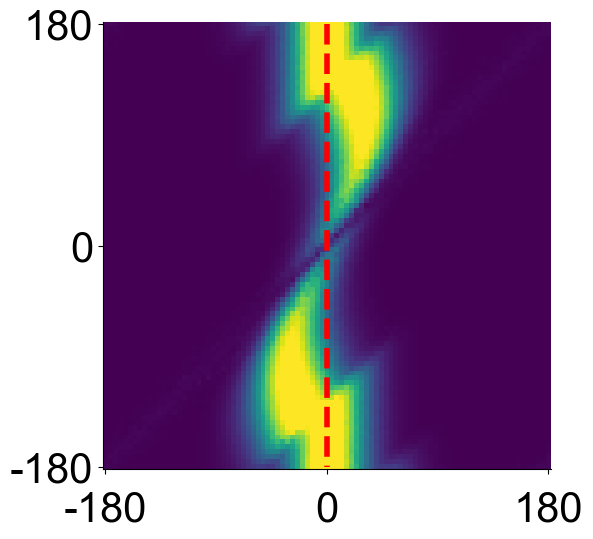

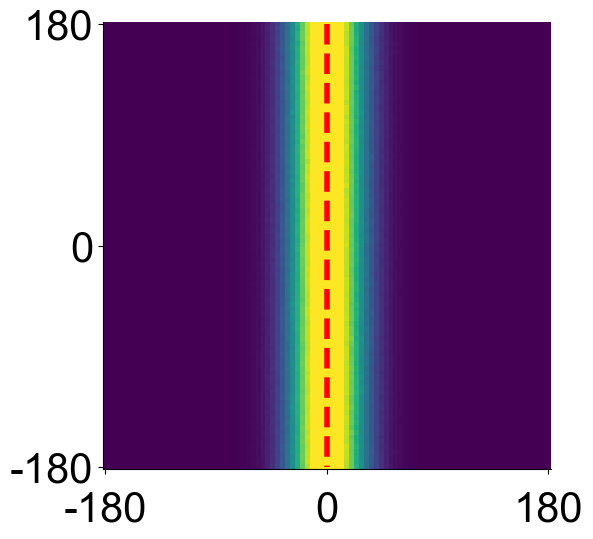

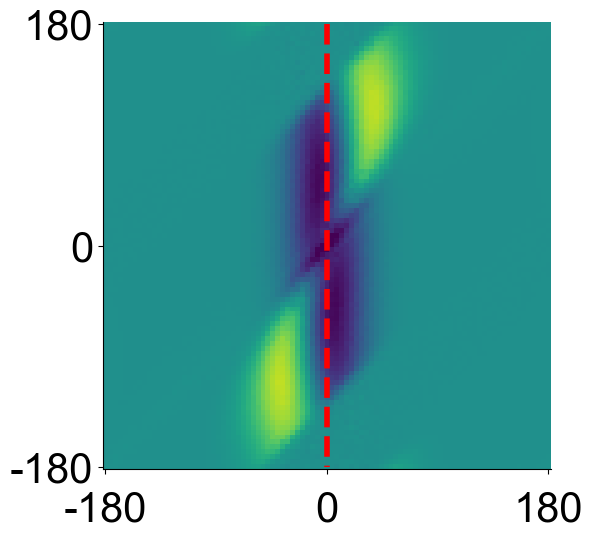

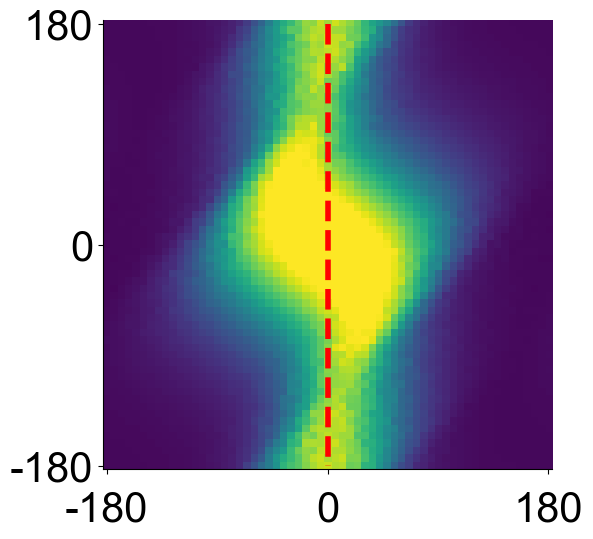

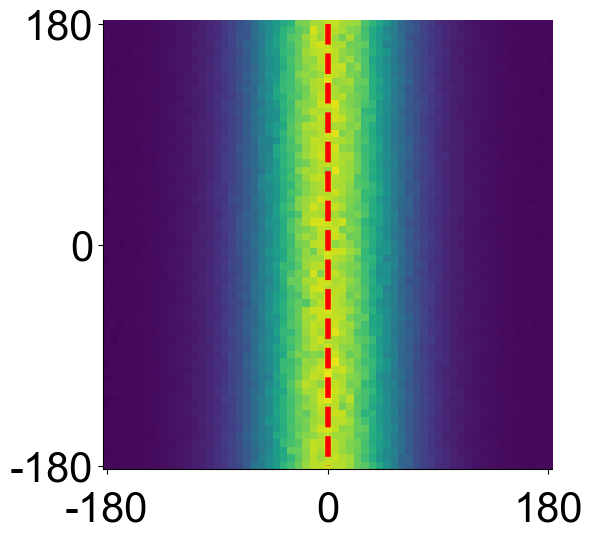

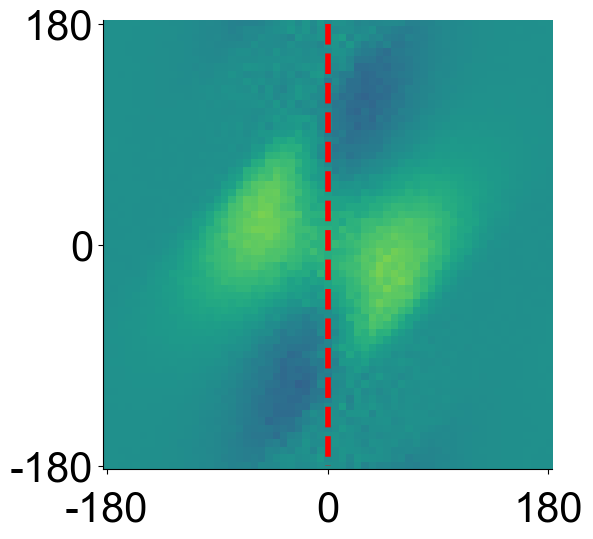

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


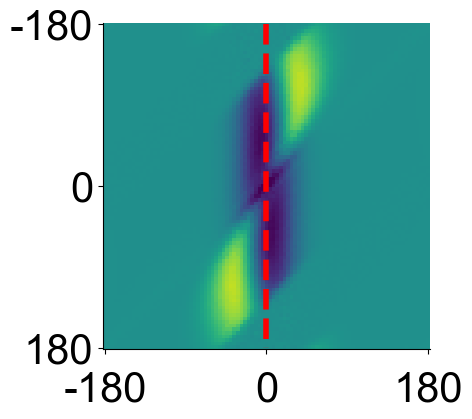

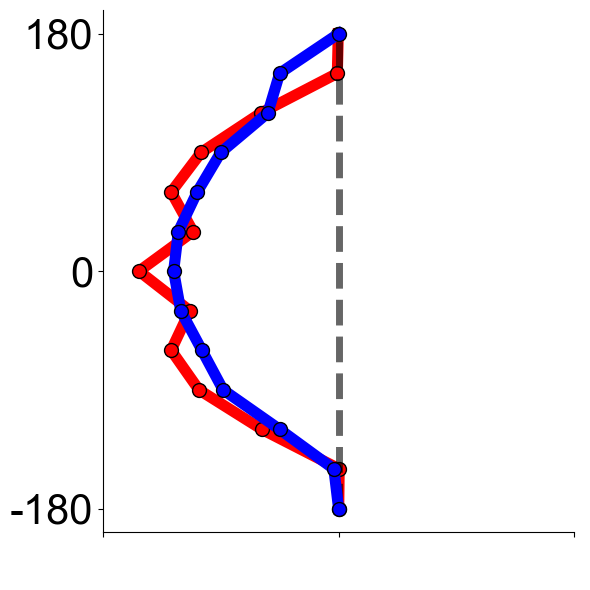

Plotting Best Fit for D0 V0 I1: (1, 4, 5)


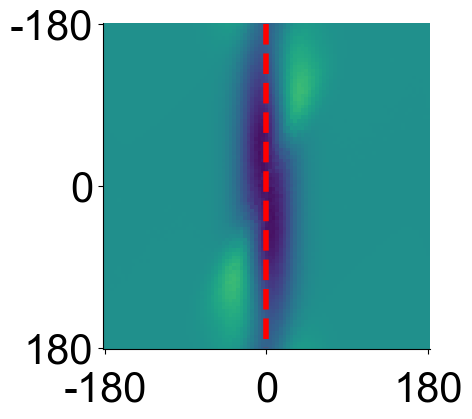

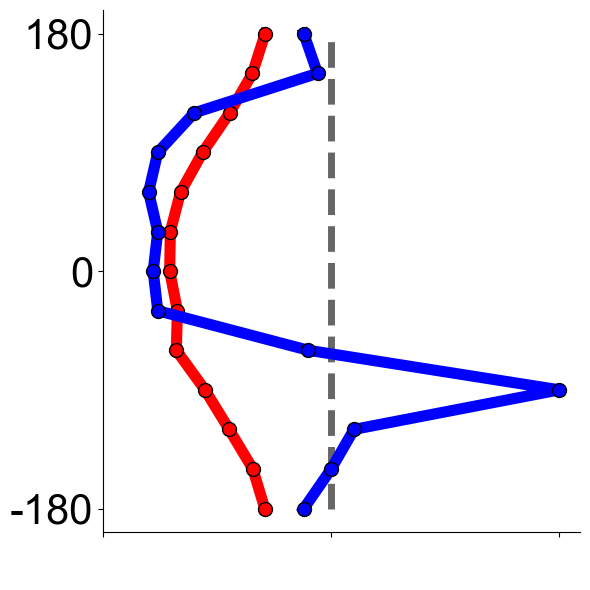

Plotting Best Fit for D0 V0 I2: (2, 4, 4)


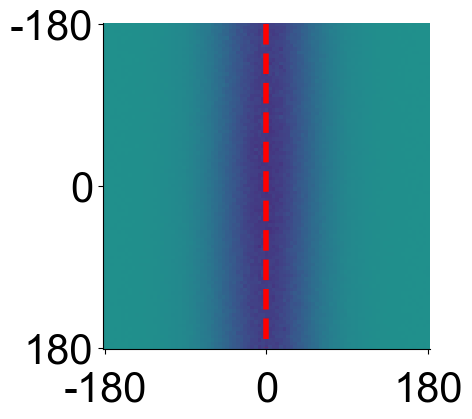

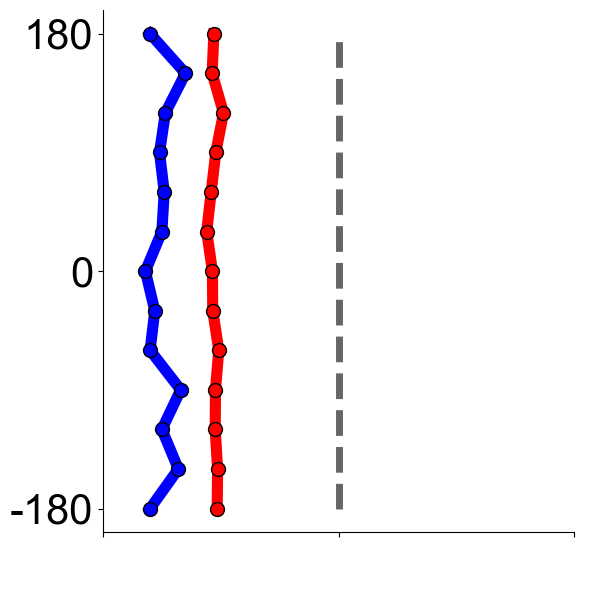

Plotting Best Fit for D0 V1 I0: (1, 1, 8)


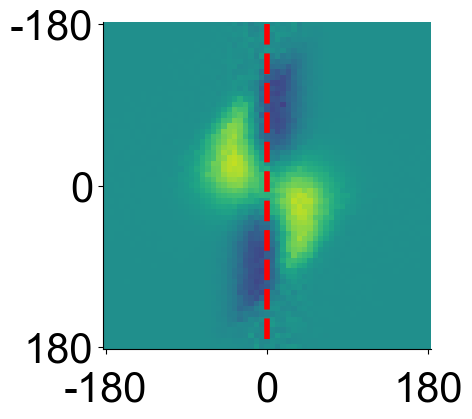

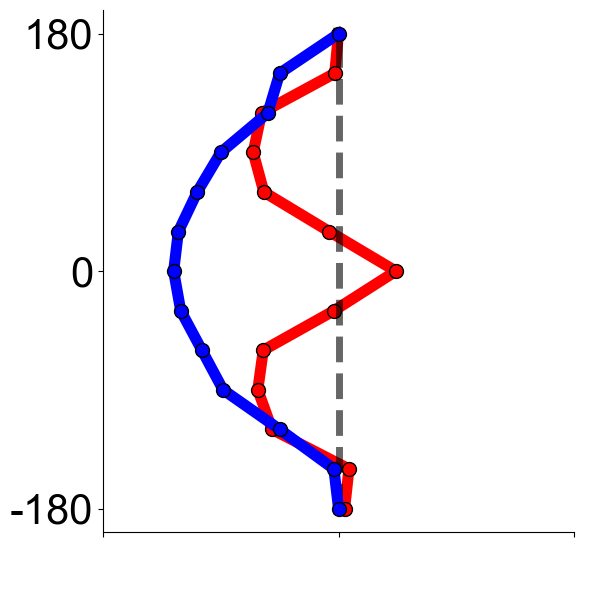

Plotting Best Fit for D0 V1 I1: (1, 2, 5)


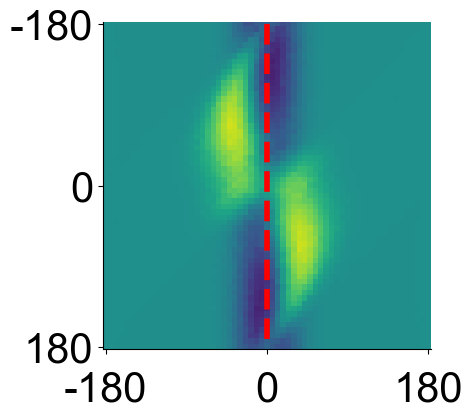

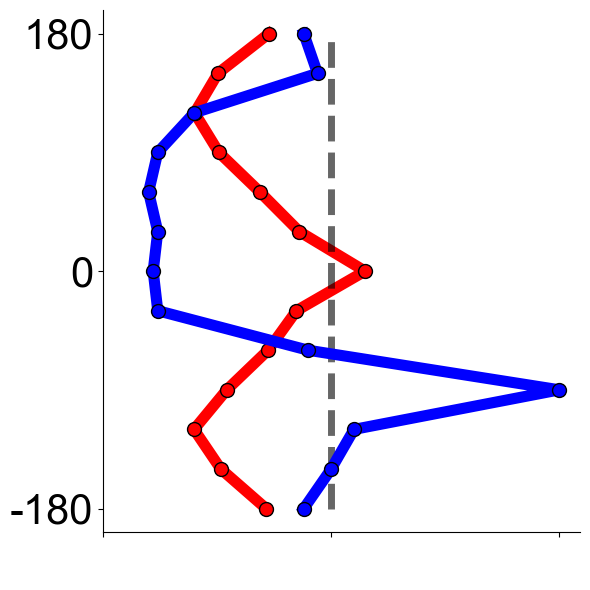

Plotting Best Fit for D0 V1 I2: (1, 2, 5)


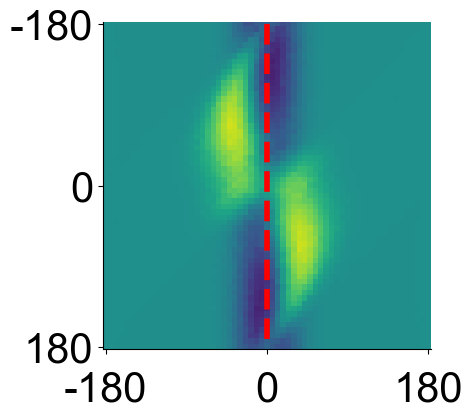

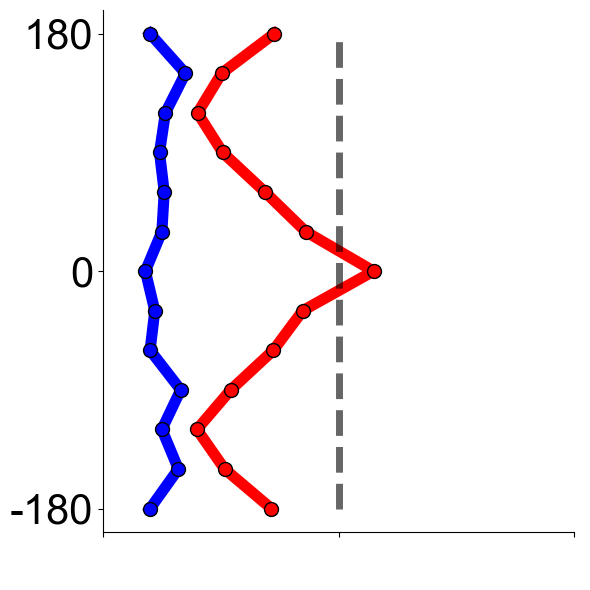

Plotting Best Fit for D1 V0 I0: (1, 2, 3)


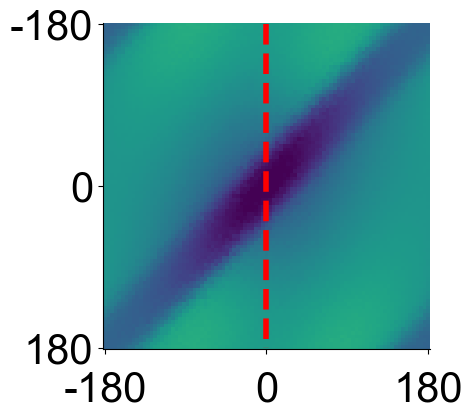

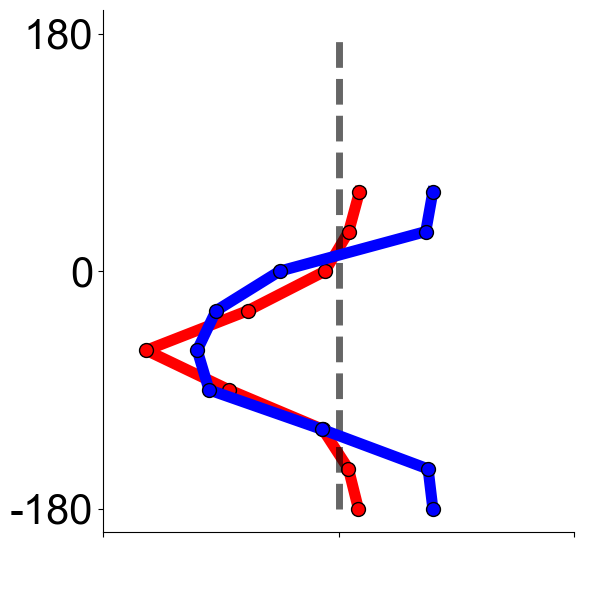

Plotting Best Fit for D1 V0 I1: (0, 0, 8)


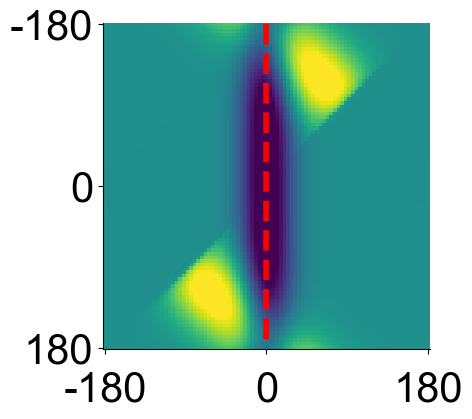

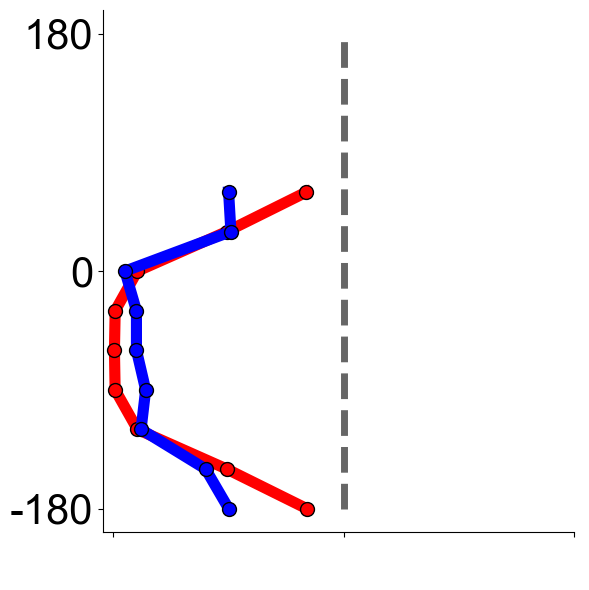

Plotting Best Fit for D1 V0 I2: (2, 1, 2)


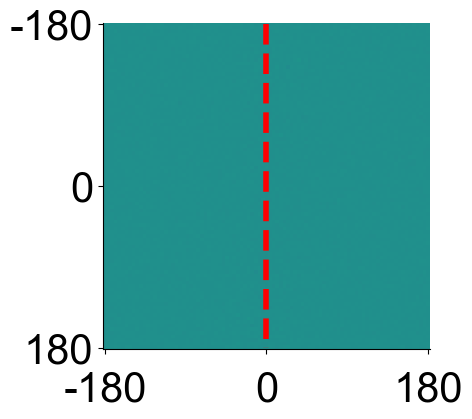

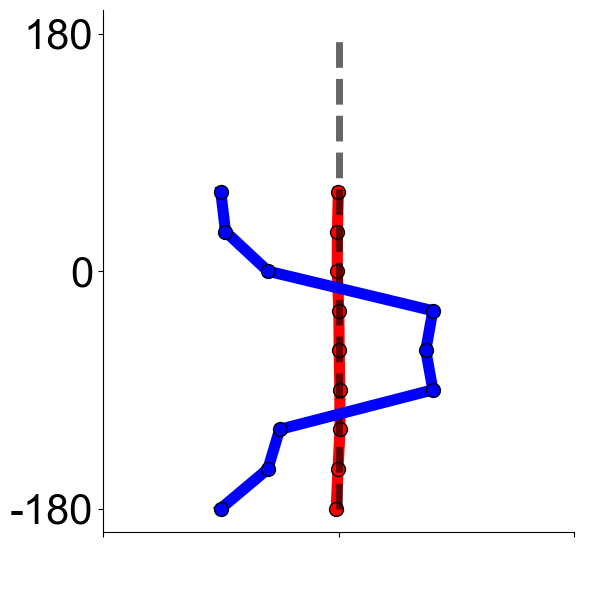

Plotting Best Fit for D1 V0 I3: (2, 1, 2)


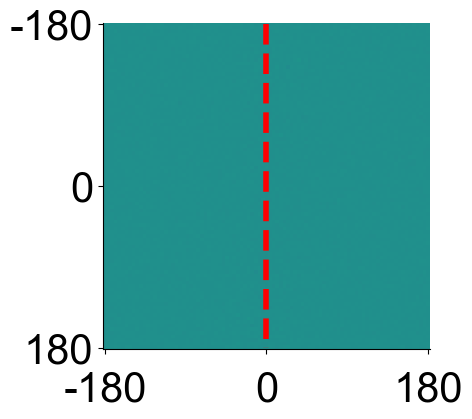

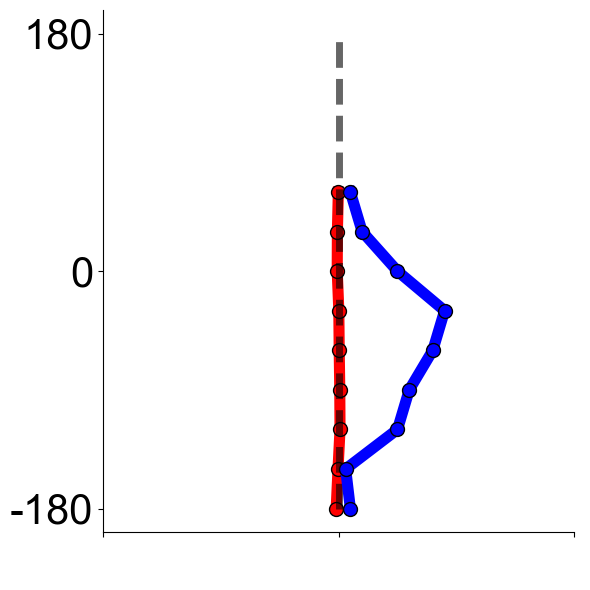

Plotting Best Fit for D1 V1 I0: (0, 0, 0)


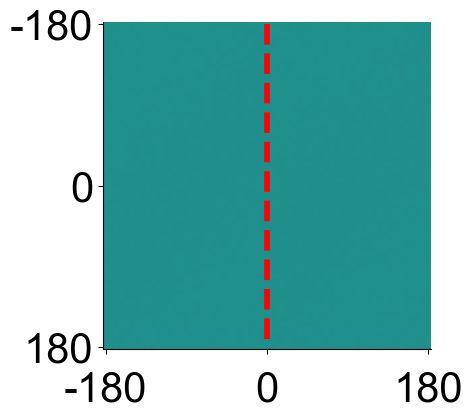

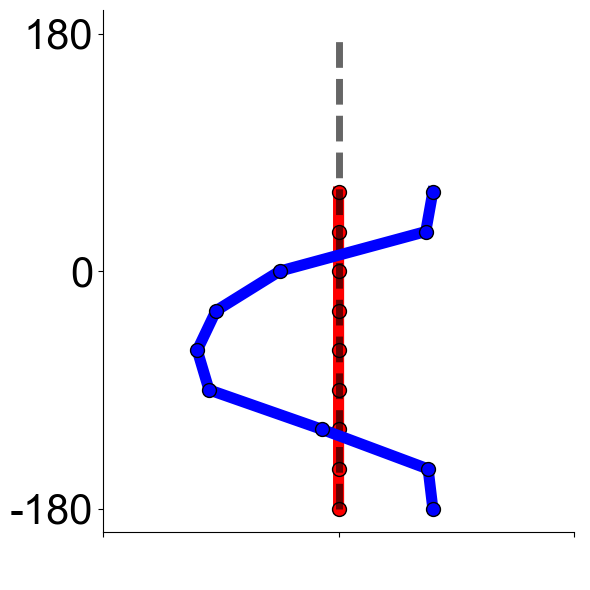

Plotting Best Fit for D1 V1 I1: (1, 2, 8)


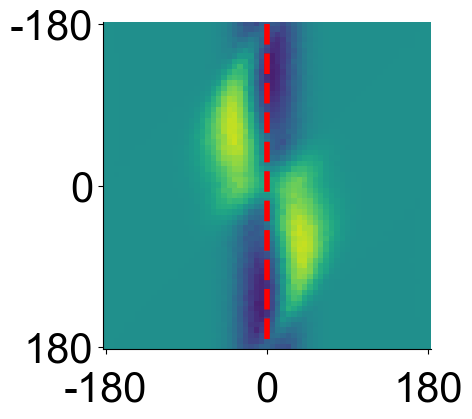

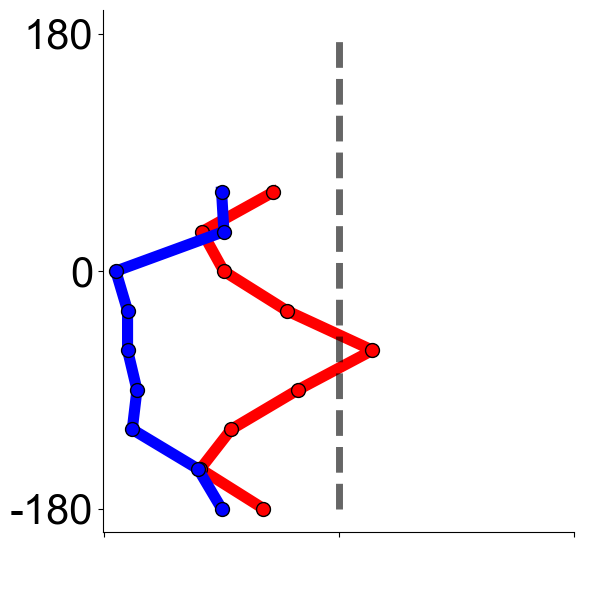

Plotting Best Fit for D1 V1 I2: (1, 2, 4)


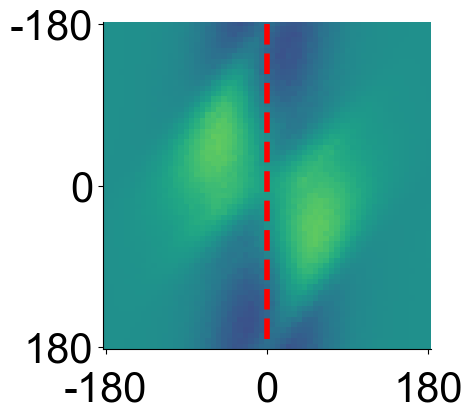

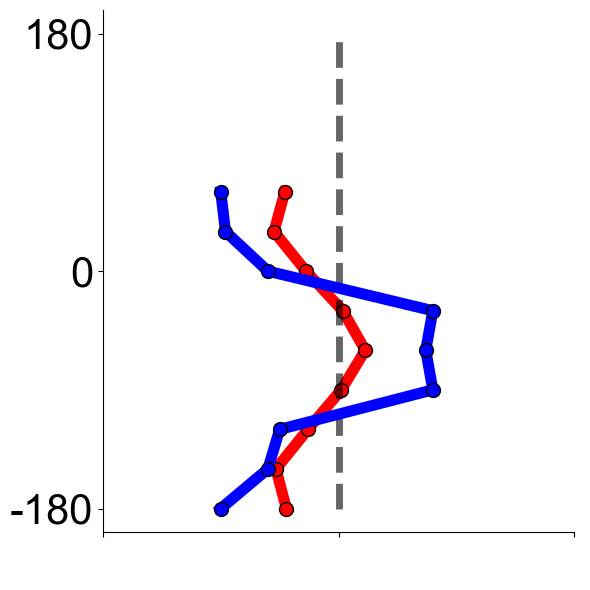

Plotting Best Fit for D1 V1 I3: (1, 1, 6)


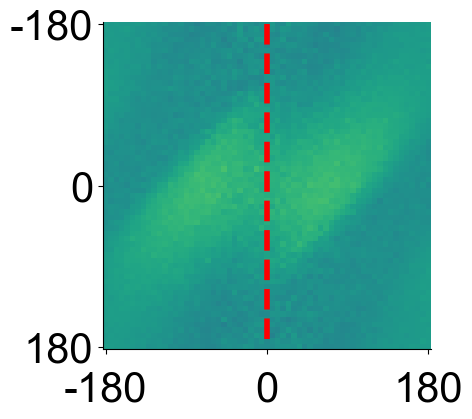

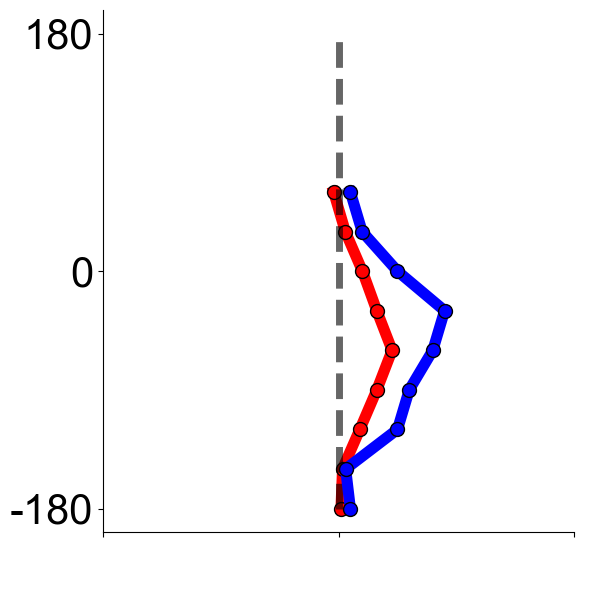

Plotting Best Fit for D2 V0 I0: (1, 2, 0)


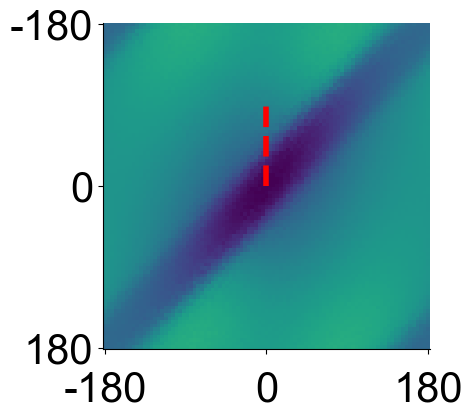

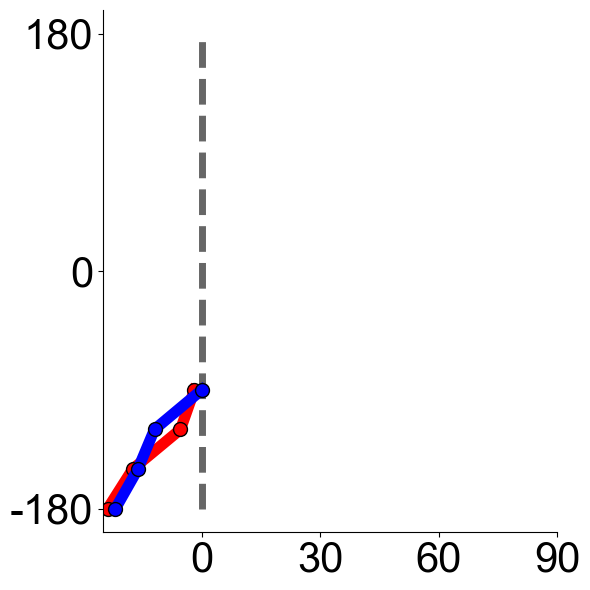

Plotting Best Fit for D2 V0 I1: (0, 1, 3)


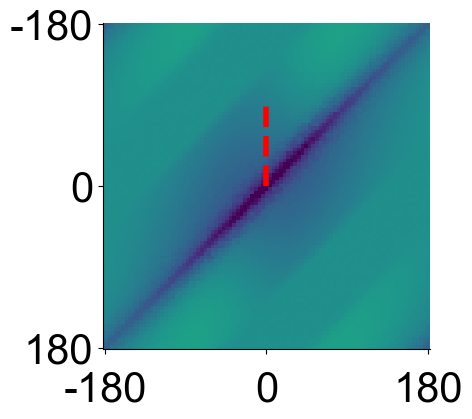

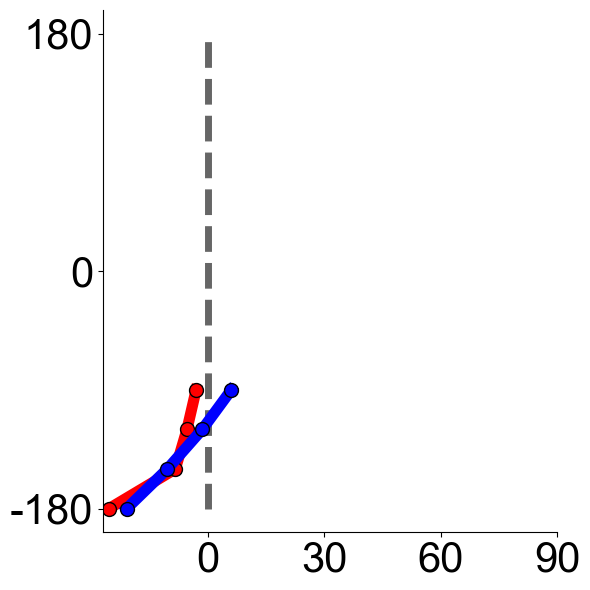

Plotting Best Fit for D2 V0 I2: (1, 4, 3)


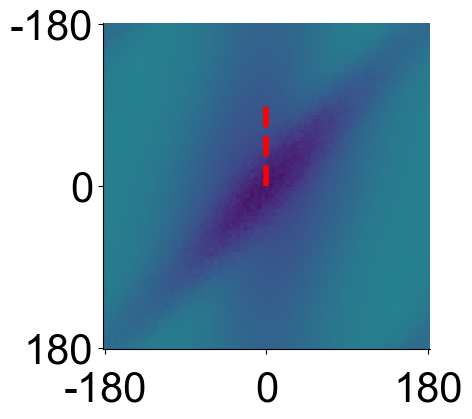

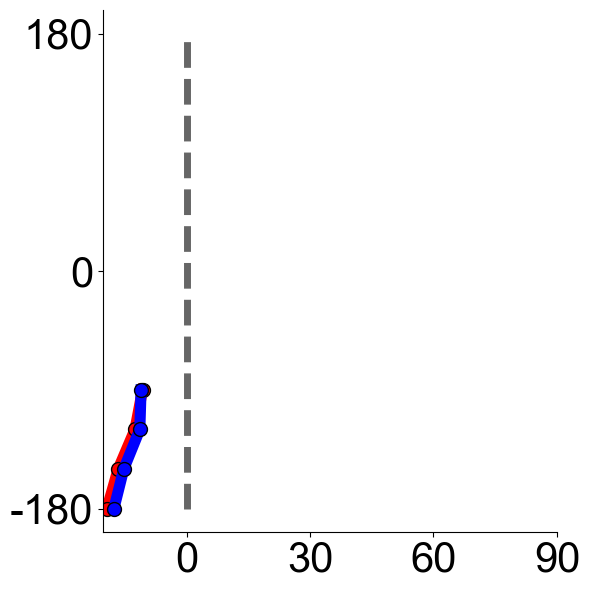

Plotting Best Fit for D2 V0 I3: (1, 2, 4)


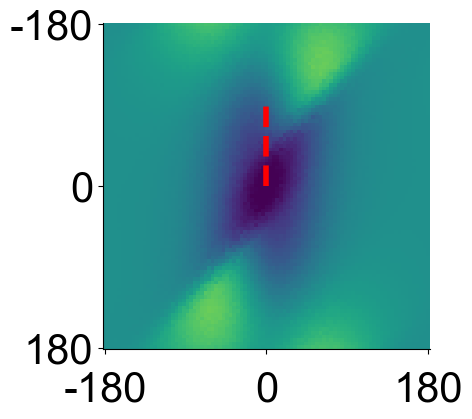

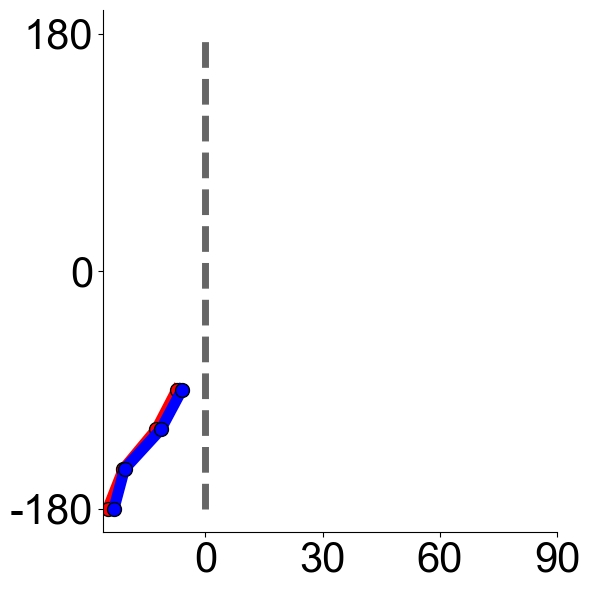

Plotting Best Fit for D2 V1 I0: (0, 3, 8)


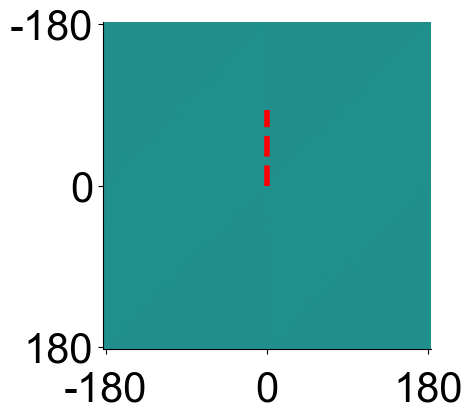

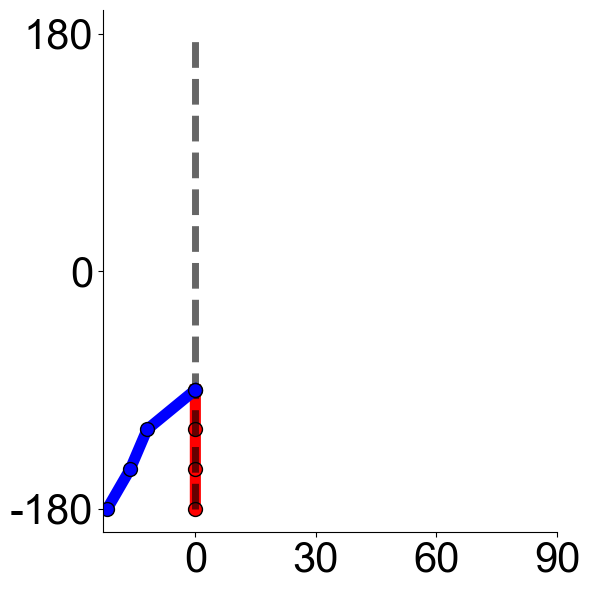

Plotting Best Fit for D2 V1 I1: (0, 0, 0)


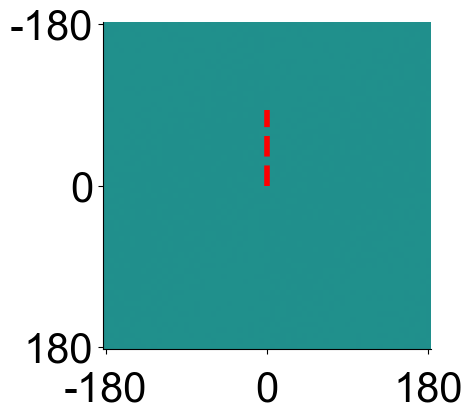

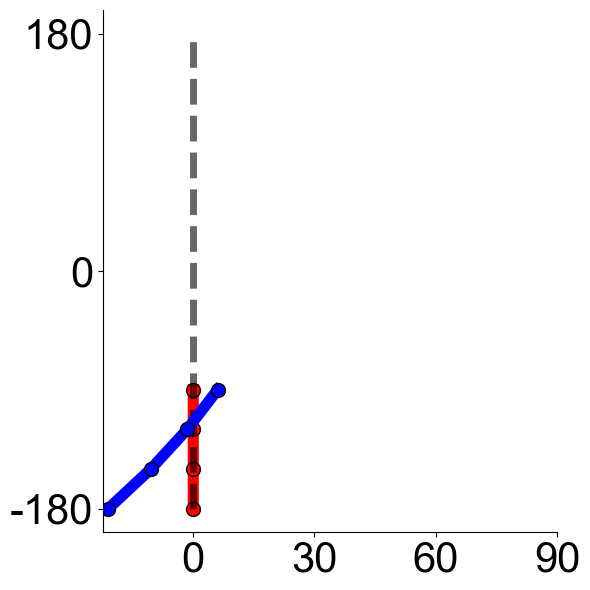

Plotting Best Fit for D2 V1 I2: (1, 2, 8)


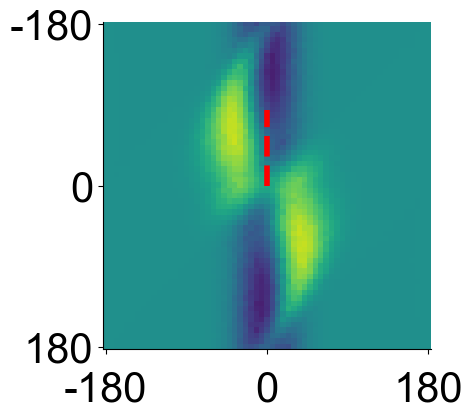

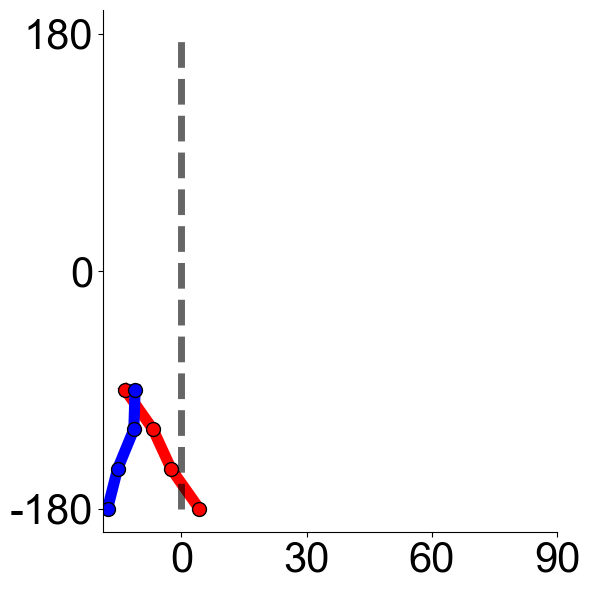

Plotting Best Fit for D2 V1 I3: (0, 3, 8)


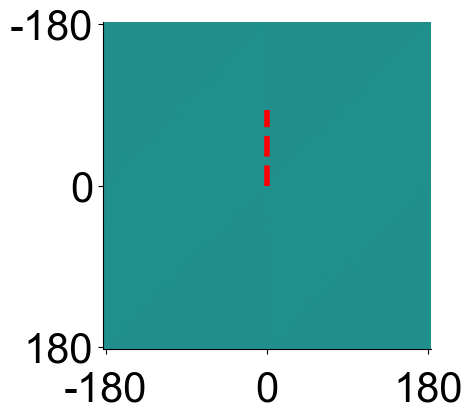

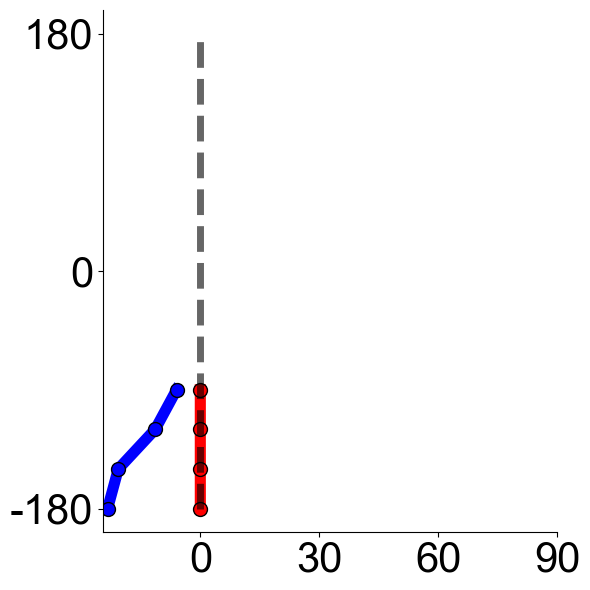

In [37]:
# Pack style params
style_params = {
    'map': parula_map, 'figS': figS, 'line_w': line_w, 
    'font': f_font1, 'sp': sp
}

# -----------------------------
# PART A: Direction Heatmaps
# -----------------------------

# 1. Subject 1 (Saccade?)
E, P, N = smeanfire1.shape[2], smeanfire1.shape[3], smeanfire1.shape[4]
R = smeanfire1.shape[0] # Response rows

# Define Ticks
ticks_1 = {'y_idx': [0, 45, 90], 'y_val': ["180", "0", "-180"],
            'x_idx': [0, 45, 90], 'x_val': ["-180", "0", "180"]}

# Define Indices for Line
ix2_1 = np.round(np.linspace(0, R-1, 13)).astype(int) # Matches Allman width
ix1_1 = 45 # Center

# Plot Comparison 1
# Selecting specific example indices (0,1,2)
i_sel = (0, 1, 2)
t1 = np.flip(smeanfire1[:,:,i_sel[0],i_sel[1],i_sel[2]].T, axis=0)
t2 = np.flip(smeanfire0[:,:,i_sel[0],i_sel[1],i_sel[2]].T, axis=0)

compare_conditions_heatmap(t1, t2, ix1_1, ix2_1, ticks_1, style_params, "CompASupp")

# 2. Subject 2 (Gaze?)
Rg = gmeanfire0.shape[0]
ticks_2 = {'y_idx': [0, 30, 60], 'y_val': ["180", "0", "-180"],
            'x_idx': [0, 30, 60], 'x_val': ["-180", "0", "180"]}

ix2_2 = np.round(np.linspace(0, Rg-1, 13)).astype(int)
ix1_2 = 30

i_sel_2 = (1, 1, 1)
t1g = np.flip(gmeanfire1[:,:,i_sel_2[0],i_sel_2[1],i_sel_2[2]].T, axis=0)
t2g = np.flip(gmeanfire0[:,:,i_sel_2[0],i_sel_2[1],i_sel_2[2]].T, axis=0)

compare_conditions_heatmap(t1g, t2g, ix1_2, ix2_2, ticks_2, style_params, "CompAFac")

# -----------------------------
# PART B: Reference Data Analysis (Direction)
# -----------------------------

# Data Definitions
allman_85 = np.array([[-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180],
                        [1,0.75,0.7,0.5,0.4,0.32,0.3,0.33,0.42,0.51,0.75,0.98,1],
                        [0.44,0.47,0.2,0.12,0.1,0.12,0.11,0.12,0.45,1,0.55,0.5,0.44],
                        [0.20,0.35,0.265,0.24,0.26,0.25,0.18,0.22,0.2,0.33,0.25,0.32,0.2]])

born2000 = np.array([[-180,-135,-90,-45,0,45,90,135,180],
                        [1,0.97,0.35,0.08,0,0.05,0.53,0.98,1],
                        [0.5,0.51,0.05,0.1,0.1,0.14,0.12,0.4,0.5],
                        [0.1,0.12,0.3,1,0.97,1,0.35,0.3,0.1],
                        [0.6,0.65,0.8,1,0.95,0.85,0.8,0.58,0.6]])

tanaka86_dir = np.array([[0,30,60,90],
                            [0.27,0.46,0.6,1],
                            [0.1,0.45,0.75,1],
                            [0.41,0.49,0.62,0.63],
                            [0.22,0.31,0.62,0.8]])

DATA = [allman_85, born2000, tanaka86_dir]

# Calculated Indices matching the data structures
ix_allman_s = np.round(np.linspace(0, R-1, len(allman_85[1,:]))).astype(int)
ix_allman_g = np.round(np.linspace(0, Rg-1, len(allman_85[1,:]))).astype(int)

ix_born_s = np.round(np.linspace(0, R-1, len(born2000[1,:]))).astype(int)
ix_born_g = np.round(np.linspace(0, Rg-1, len(born2000[1,:]))).astype(int)

# Tanaka indices hardcoded as in original
ix_tanaka_s = [45, 37, 30, 22]
ix_tanaka_g = [30, 26, 21, 16]

ixDATA = [[ix_allman_s, ix_allman_g],
            [ix_born_s, ix_born_g],
            [ix_tanaka_s, ix_tanaka_g]]
            
bDATA = [[1,1,1,1], [0.6,1,0.6,0.55], [1,0.8,1,1]] # Biases

dataset_pairs = [[smeanfire1, smeanfire0], [gmeanfire1, gmeanfire0]]
ix1_centers = [45, 30]

# Run Analysis
CO, RM = run_correlation_analysis(dataset_pairs, DATA, ixDATA, bDATA, 
                                    E, P, N, ix1_centers)

# Plot Best Fits (2D Heatmap & 1D Curves)
# Ticks for result plots
tckixM_list = [[0, 45, 90], [0, 30, 60]]

s_count = 0 
for di, D in enumerate(DATA):
    tp = D.shape[0] - 1
    ix2_list = ixDATA[di]
    b_list = bDATA[di]

    for v, T in enumerate(dataset_pairs):
        for i in range(tp):
            # Find best Fit index from RMSE
            best_idx = np.unravel_index(np.argmin(RM[di][v,i]), RM[di][v,i].shape)
            print(f"Plotting Best Fit for D{di} V{v} I{i}: {best_idx}")
            
            # --- Plot 2D Heatmap ---
            t1 = np.flip(T[0][:,:,best_idx[0], best_idx[1], best_idx[2]].T, axis=0)
            t2 = np.flip(T[1][:,:,best_idx[0], best_idx[1], best_idx[2]].T, axis=0)
            diff_map = t1 - t2
            
            # Setup ticks for this specific map
            ticks_map = {
                'y_idx': tckixM_list[v], 'y_val': ["-180", "0", "180"],
                'x_idx': tckixM_list[v], 'x_val': ["-180", "0", "180"]
            }
            
            plot_heatmap(diff_map, ix1_centers[v], ix2_list[v], 
                            ticks_map['y_idx'], ticks_map['y_val'],
                            ticks_map['x_idx'], ticks_map['x_val'],
                            parula_map, -0.8, 0.8, figS*0.8, line_w, f_font1,
                            sp, f"CompBCD_2D{s_count}.pdf")
            
            # --- Plot 1D Curve Comparison ---
            # Prepare traces
            neural_trace = diff_map[ix2_list[v], ix1_centers[v]]
            
            if di == 2: # Tanaka (special case)
                ref_trace = D[i+1, :] - b_list[i]
                x_tick_labels = ["0", "30", "60", "90"]
                # X ticks for Tanaka are just 0..3 indices? 
                # Original code used tckiy=[-1,0,1] for x-axis which seems wrong for length 4 data?
                # Adjusting to simple indices
                tick_idx_curve = [0, 1, 2, 3]
            else:
                if (i == 1) and (di == 0): # Specific Allman condition flip
                        ref_trace = np.flip(D[i+1, :]) * 2 - b_list[i]
                else:
                    ref_trace = np.flip(D[i+1, :] - b_list[i])
                
                x_tick_labels = [" ", " ", " "] # Hidden
                tick_idx_curve = [-1, 0, 1] # Placeholder
            
            # Ticks for the 1D plot
            ticks_curve = {
                'y_idx': [0, 6, 12], 'y_val': ["-180", "0", "180"], # Y is now Direction?
                'x_idx': tick_idx_curve, 'x_val': x_tick_labels
            }
            
            plot_fit_comparison(neural_trace, ref_trace, 
                                ix2_list[v], None, 
                                ticks_curve, None,
                                style_params, f"CompBCD{s_count}.pdf")
            s_count += 1

## Fitting the predictions across CS Speeds

--- Speed Analysis ---
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel

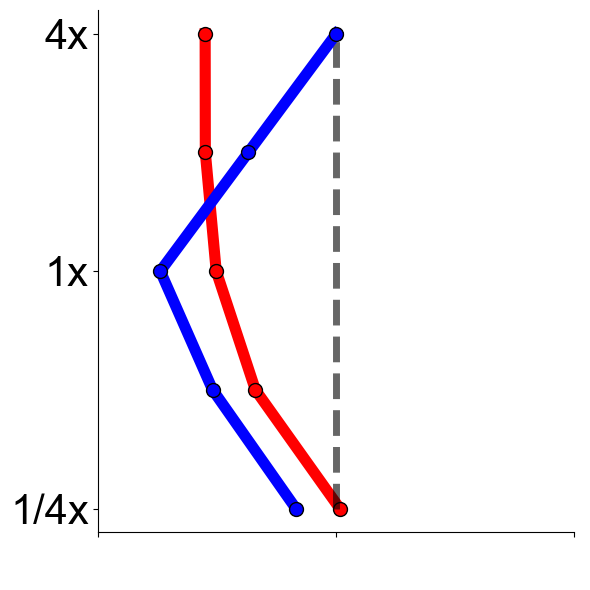

Speed V0 Cond 1: Best Fit at (1, 2, 6)


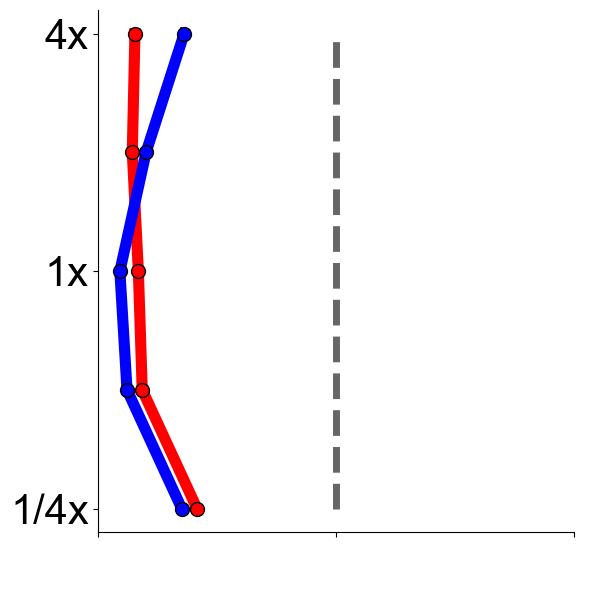

Speed V0 Cond 2: Best Fit at (1, 1, 8)


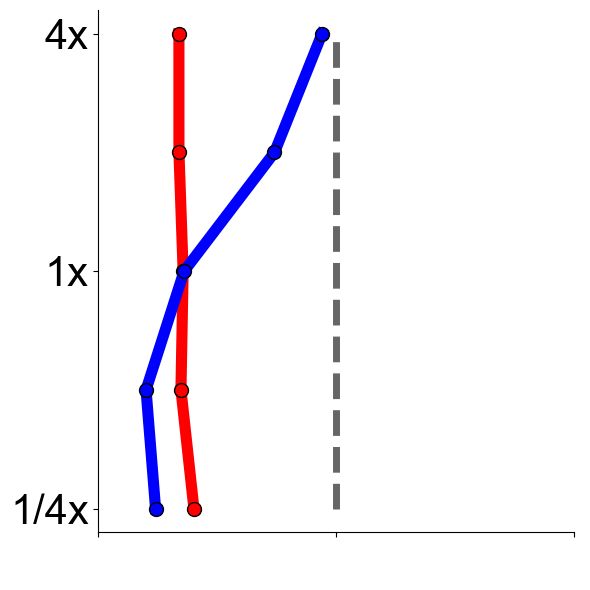

Speed V0 Cond 3: Best Fit at (1, 2, 7)


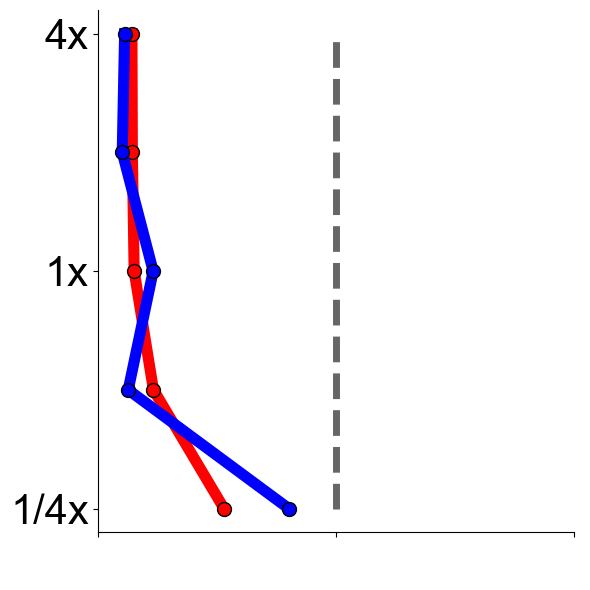

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


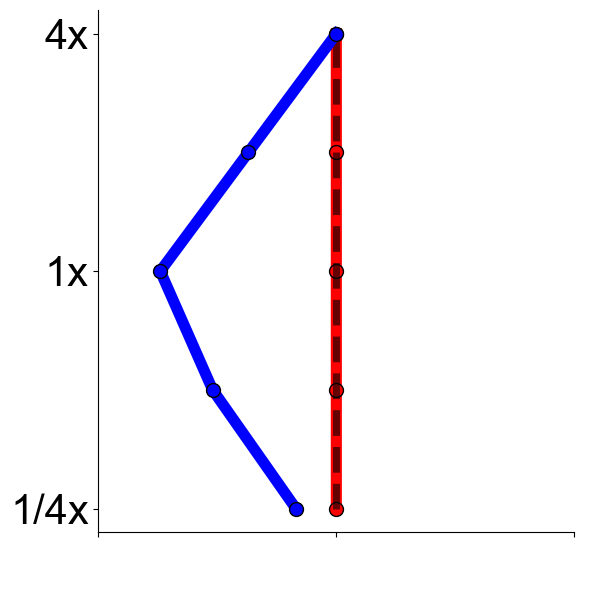

Speed V1 Cond 1: Best Fit at (2, 0, 5)


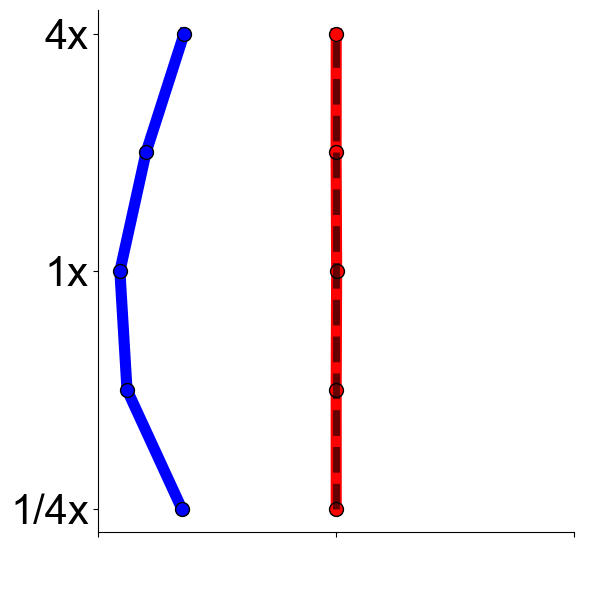

Speed V1 Cond 2: Best Fit at (2, 0, 5)


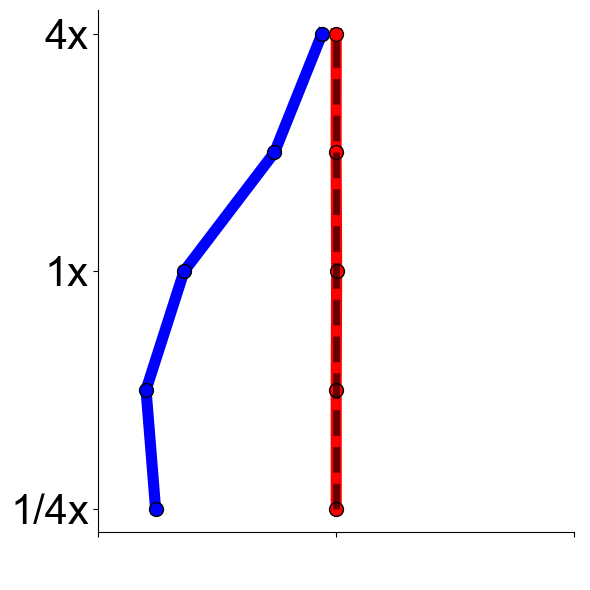

Speed V1 Cond 3: Best Fit at (2, 0, 5)


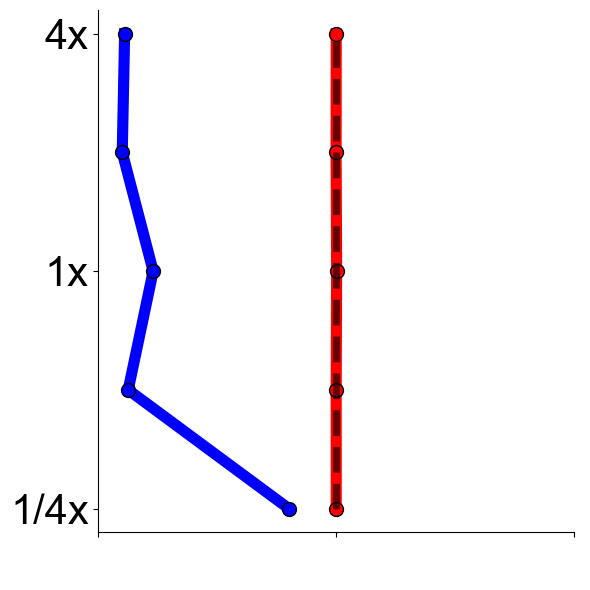

In [39]:
    # -----------------------------
    # PART C: Speed Analysis
    # -----------------------------
    print("--- Speed Analysis ---")
    
    tanaka86_spd = np.array([[0,1,2,3,4],
                             [0.83,0.48,0.26,0.63,1],
                             [0.35,0.12,0.09,0.2,0.36],
                             [0.24,0.2,0.36,0.74,0.94],
                             [0.8,0.125,0.23,0.10,0.11]])
    
    b_spd = 1
    dataset_pairs_spd = [[smeanfire1_s, smeanfire0_s], [gmeanfire1_s, gmeanfire0_s]]
    
    # 1. Compute Fits (Speed is 4D [E,P,N], not 5D spatial map)
    # The original code nested loops manually. We can do it cleaner.
    
    for v, T in enumerate(dataset_pairs_spd):
        # T[0] shape: [Time, E, P, N]? Or [Time, Speed]?
        # Original: t1 = T[0][:,e,p,n]. This implies dim 0 is Time/SpeedStep
        
        # Dimensions
        num_speeds = 4
        # Assuming E, P, N are same as before or derived from T
        E_s, P_s, N_s = T[0].shape[1], T[0].shape[2], T[0].shape[3]
        
        corr = np.zeros((num_speeds, E_s, P_s, N_s))
        RMSE = np.zeros((num_speeds, E_s, P_s, N_s))
        
        for e in range(E_s):
            for p in range(P_s):
                for n in range(N_s):
                    # Difference curve (length 4 or 5?)
                    # Tanaka has 5 cols (index row + 4 data points?)
                    # original: "for j in range(4): tanaka86[j+1,:]" -> Rows 1-4 are conditions
                    # "tanaka86[j+1,:]" shape is 5.
                    # "t1 = T[0][:,e,p,n]" shape must be 5 to match?
                    
                    t_curve = T[0][:, e, p, n] - T[1][e, p, n]
                    
                    for j in range(num_speeds):
                        ref_curve = tanaka86_spd[j+1, :] - b_spd
                        # Correlation
                        corr[j,e,p,n] = np.corrcoef(t_curve, ref_curve)[0, 1]
                        RMSE[j,e,p,n] = np.sqrt(np.mean((t_curve - ref_curve)**2))
        
        # Plot Best Speed Fits
        surrIx = range(0, 5) # Y-axis for plot?
        ticks_spd = {
            'y_idx': [0, 2, 4], 'y_val': ["1/4x", "1x", "4x"],
            'x_idx': [-1, 0, 1], 'x_val': [" ", " ", " "]
        }

        for i in range(num_speeds):
            best_idx = np.unravel_index(np.argmin(RMSE[i]), RMSE[i].shape)
            print(f"Speed V{v} Cond {i}: Best Fit at {best_idx}")
            
            # Manual override examples from original code
            # if i==0: best_idx=(2,0,6) ...
            
            t_curve = T[0][:, best_idx[0], best_idx[1], best_idx[2]] - T[1][best_idx[0], best_idx[1], best_idx[2]]
            ref_curve = tanaka86_spd[i+1, :] - b_spd
            
            # Plot
            plot_fit_comparison(t_curve, ref_curve, surrIx, None, 
                                ticks_spd, None, style_params, 
                                f"CompD_spd{i}{v}.pdf")